<a href="https://colab.research.google.com/github/Thanchanya309/DW_lab_6730202540/blob/main/SC663402_Pandas_Review_673020254_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

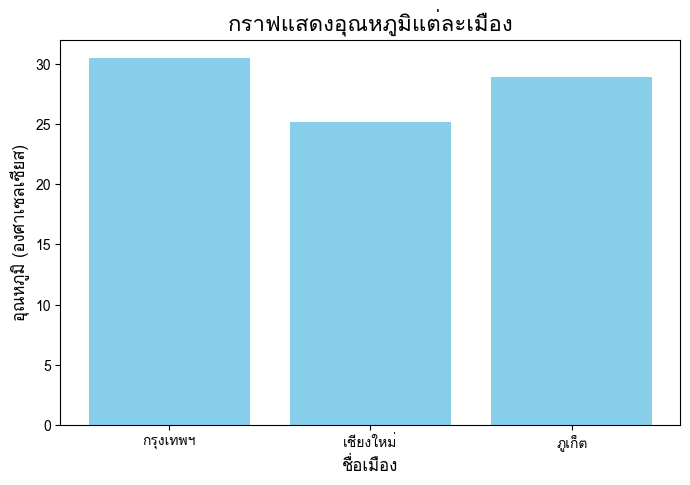

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


### สรุปข้อ 1
- **1.1** `s["a"]` และ `s.iloc[0]` คืนค่าเดี่ยว (scalar) แต่ `s[["a", "c"]]` คืน `Series` หลายสมาชิก; ใช้ label เมื่อชื่อ index มีความหมาย และใช้ `iloc` เมื่อต้องการอ้างตามตำแหน่ง
- **1.2** `df["city"]` เป็น `Series` หนึ่งมิติ รูปร่าง `(n,)` ส่วน `df[["city"]]` เป็น `DataFrame` สองมิติ รูปร่าง `(n, 1)`; เลือกตามชนิดข้อมูลที่ฟังก์ชันขั้นถัดไปต้องการ
- **1.3** `loc[0:3]` รวม label ปลายทาง จึงได้ 4 แถวเมื่อ index เป็น 0,1,2,3 ส่วน `iloc[0:3]` ไม่รวมตำแหน่ง 3 จึงได้ 3 แถว
- **1.4** `count()` นับเฉพาะค่าที่ไม่เป็น NaN ในคอลัมน์ที่เลือก ส่วน `size()` นับจำนวนแถวทั้งหมดของแต่ละกลุ่ม; ใช้ `size` เมื่อต้องการขนาดกลุ่มจริง และ `count` เมื่อต้องการจำนวนค่าที่สังเกตได้
- **1.5** การเลือก `['temperature_c']` ก่อน `mean()` ให้ `Series` ส่วนเลือก `[['temperature_c']]` ให้ `DataFrame`; ค่าคำนวณเหมือนกันแต่โครงสร้างผลต่างกัน
- **1.6** การบวก `Series` จับคู่ตาม index label ก่อน (`x` กับ `x`) ส่วน `.to_numpy()` ทิ้ง label แล้วบวกตามตำแหน่ง จึงอาจได้ความหมายต่างกันเมื่อ index เรียงไม่เหมือนกัน

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [9]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [10]:
# คำตอบข้อ 2.1
rain_by_city = df.groupby("city")["rainfall_mm"].sum()
print("1) เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก")
print(rain_by_city.nlargest(3))

rain_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("\n2) สัดส่วนปริมาณฝนของแต่ละเมือง (%)")
print(rain_pct.sort_values(ascending=False))

n_above_mean = (rain_by_city > rain_by_city.mean()).sum()
print("\n3) จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย =", n_above_mean)


1) เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

2) สัดส่วนปริมาณฝนของแต่ละเมือง (%)
city
Singapore       10.43
Bangkok          8.21
Lagos            7.82
Mumbai           5.84
Chiang Mai       5.22
Sao Paulo        5.07
Nairobi          4.74
Tokyo            4.61
Auckland         4.22
Paris            3.99
Sydney           3.97
Toronto          3.81
New York         3.78
Mexico City      3.66
Buenos Aires     3.65
London           3.27
Berlin           3.21
Beijing          3.00
Moscow           2.96
Cape Town        2.87
Lima             2.16
Los Angeles      2.03
Cairo            1.47
Name: rainfall_mm, dtype: float64

3) จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย = 8


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [11]:
# คำตอบข้อ 2.2
city_profile = (df.groupby(["city", "country", "region"], as_index=False)
                  .agg(n_records=("record_id", "size"),
                       avg_temp=("temperature_c", "mean"),
                       total_rain=("rainfall_mm", "sum")))
city_profile


,city,country,region,n_records,avg_temp,total_rain
0,Auckland,NEW ZEALAND,Oceania,1,19.800000,3.5
1,Auckland,New Zealand,Oceania,89,17.782022,348.4
2,Bangkok,Thailand,Asia,91,32.453846,685.6
3,Beijing,China,Asia,90,15.598876,250.1
4,Berlin,GERMANY,Europe,1,14.700000,0.0
5,Berlin,Germany,Europe,89,12.356818,268.4
6,Buenos Aires,ARGENTINA,South America,1,22.200000,9.3
7,Buenos Aires,Argentina,South America,89,19.137500,295.8
8,Cairo,Egypt,Africa,91,26.089888,123.0
9,Cape Town,South Africa,Africa,90,30.162921,239.3


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [12]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [13]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [14]:
# คำตอบข้อ 3.1
weather_opt = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city"
)
print(weather_opt.dtypes)
weather_opt.info()


date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [15]:
# คำตอบข้อ 3.2
weather_normal = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"]
).set_index("city")

mem_normal_by_col = weather_normal.memory_usage(deep=True)
mem_opt_by_col = weather_opt.memory_usage(deep=True)
mem_normal = mem_normal_by_col.sum()
mem_opt = mem_opt_by_col.sum()
pct_reduction = (1 - mem_opt / mem_normal) * 100

comparison = pd.DataFrame({"normal_bytes": mem_normal_by_col, "optimized_bytes": mem_opt_by_col})
comparison["saved_bytes"] = comparison["normal_bytes"] - comparison["optimized_bytes"]
print(comparison.sort_values("saved_bytes", ascending=False))
print(f"\nหน่วยความจำลดลง {pct_reduction:.2f}%")
print("อธิบาย: คอลัมน์ข้อความ โดยเฉพาะ region (และ city ที่ถูกใช้เป็น index) มีผลมาก เพราะ category เก็บรหัสหมวดหมู่แทนการเก็บสตริงซ้ำทุกแถว ส่วน parse_dates เปลี่ยน date จาก object เป็น datetime64 ซึ่งมีขนาดคงที่และประหยัดกว่าการเก็บข้อความซ้ำ ๆ")


               normal_bytes  optimized_bytes  saved_bytes
region               117631             2590       115041
Index                116920             3927       112993
date                 122425            16600       105825
temperature_c         16600            16600            0
humidity_pct          16600            16600            0
rainfall_mm           16600            16600            0

หน่วยความจำลดลง 82.07%
อธิบาย: คอลัมน์ข้อความ โดยเฉพาะ region (และ city ที่ถูกใช้เป็น index) มีผลมาก เพราะ category เก็บรหัสหมวดหมู่แทนการเก็บสตริงซ้ำทุกแถว ส่วน parse_dates เปลี่ยน date จาก object เป็น datetime64 ซึ่งมีขนาดคงที่และประหยัดกว่าการเก็บข้อความซ้ำ ๆ


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [16]:
# คำตอบข้อ 3.3
file_url = BASE + "world_weather_sample.csv"
global_min, global_max = np.inf, -np.inf
city_sum = {}
city_count = {}

for chunk in pd.read_csv(file_url, usecols=["city", "temperature_c"], chunksize=500,
                         na_values=[999, -999]):
    global_min = min(global_min, chunk["temperature_c"].min(skipna=True))
    global_max = max(global_max, chunk["temperature_c"].max(skipna=True))
    g = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])
    for city, row in g.iterrows():
        city_sum[city] = city_sum.get(city, 0) + row["sum"]
        city_count[city] = city_count.get(city, 0) + row["count"]

city_mean = (pd.Series(city_sum) / pd.Series(city_count)).sort_index()
print("อุณหภูมิต่ำสุด =", global_min)
print("อุณหภูมิสูงสุด =", global_max)
print("\nอุณหภูมิเฉลี่ยรายเมือง")
print(city_mean)
print("\nอธิบาย: ค่าเฉลี่ยของแต่ละ chunk ไม่ควรนำมาเฉลี่ยตรง ๆ เพราะแต่ละ chunk หรือแต่ละเมืองใน chunk อาจมีจำนวนข้อมูลไม่เท่ากัน จึงต้องสะสมผลรวม (sum) และจำนวนค่าที่ไม่ว่าง (count) แล้วคำนวณ sum/count หลังอ่านครบทุกก้อน")


อุณหภูมิต่ำสุด = -88.0
อุณหภูมิสูงสุด = 39.2

อุณหภูมิเฉลี่ยรายเมือง
Auckland        17.804444
Bangkok         32.453846
Beijing         15.598876
Berlin          12.383146
Buenos Aires    19.171910
Cairo           26.089888
Cape Town       19.153409
Chiang Mai      29.680220
Lagos           29.494253
Lima            21.490000
London          13.490909
Los Angeles     20.657303
Mexico City     19.187778
Moscow           7.233333
Mumbai          30.872222
Nairobi         21.440000
New York        15.476667
Paris           14.752273
Sao Paulo       22.841573
Singapore       29.308989
Sydney          20.347778
Tokyo           18.414773
Toronto         11.613636
dtype: float64

อธิบาย: ค่าเฉลี่ยของแต่ละ chunk ไม่ควรนำมาเฉลี่ยตรง ๆ เพราะแต่ละ chunk หรือแต่ละเมืองใน chunk อาจมีจำนวนข้อมูลไม่เท่ากัน จึงต้องสะสมผลรวม (sum) และจำนวนค่าที่ไม่ว่าง (count) แล้วคำนวณ sum/count หลังอ่านครบทุกก้อน


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [18]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [19]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [20]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "example_value": df.bfill().iloc[0]
}).sort_values(["n_missing", "pct_missing"], ascending=False)
summary


,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
wind_speed_kmh,float64,41,1.98,278,15.9
pressure_hpa,float64,32,1.54,294,1005.4
temperature_c,float64,20,0.96,331,15.7
record_id,int64,0,0.00,2070,983
date,object,0,0.00,90,2025-03-24
city,object,0,0.00,23,New York
country,object,0,0.00,28,USA
region,object,0,0.00,6,North America


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [21]:
# คำตอบข้อ 4.2
bad_temp = df["temperature_c"].notna() & ~df["temperature_c"].between(-60, 60)
bad_humidity = df["humidity_pct"].notna() & ~df["humidity_pct"].between(0, 100)
print("temperature_c ผิดช่วง =", bad_temp.sum())
print("humidity_pct ผิดช่วง =", bad_humidity.sum())
print("ผิดปกติอย่างน้อยหนึ่งคอลัมน์ =", (bad_temp | bad_humidity).sum())


temperature_c ผิดช่วง = 5
humidity_pct ผิดช่วง = 3
ผิดปกติอย่างน้อยหนึ่งคอลัมน์ = 8


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [22]:
# คำตอบข้อ 4.3
country_raw = df["country"].astype("string")
country_key = country_raw.str.strip().str.casefold()
variants = (pd.DataFrame({"key": country_key, "raw": country_raw.str.strip()})
              .dropna().drop_duplicates()
              .groupby("key")["raw"].agg(list))
print("1) ประเทศที่มีรูปแบบการเขียนมากกว่า 1 แบบ")
print(variants[variants.str.len() > 1])

print("\n2) ค่าที่เปลี่ยนเมื่อใช้ str.title()")
titled = country_raw.str.strip().str.title()
print(pd.DataFrame({"เดิม": country_raw.str.strip(), "title": titled})
      .drop_duplicates().query("เดิม != title"))
print("อธิบาย: str.title() เปลี่ยนตัวพิมพ์ตามรูปแบบ Title Case โดยอัตโนมัติ จึงทำให้ชื่อที่เป็นตัวย่อ เช่น USA กลายเป็น Usa และเสียรูปแบบชื่อประเทศที่ควรเก็บไว้")

canonical = (country_raw.str.strip().str.casefold()
             .replace({"usa": "USA", "uk": "UK"}))
# สำหรับชื่อทั่วไป ใช้ mapping จาก casefold key ไปยังรูปแบบที่พบบ่อยที่สุดในข้อมูล
mode_map = (pd.DataFrame({"key": country_key, "raw": country_raw.str.strip()})
            .dropna().groupby("key")["raw"].agg(lambda s: s.mode().iat[0]))
country_normalized = country_key.map(mode_map).replace({"Usa": "USA", "usa": "USA", "Uk": "UK", "uk": "UK"})
df["country_normalized"] = country_normalized
print("\n3) จำนวนประเทศหลัง normalize =", df["country_normalized"].nunique())
print(df[["country", "country_normalized"]].drop_duplicates().sort_values("country_normalized"))


1) ประเทศที่มีรูปแบบการเขียนมากกว่า 1 แบบ
key
argentina          [Argentina, ARGENTINA]
canada                   [Canada, CANADA]
germany                [Germany, GERMANY]
japan                      [Japan, JAPAN]
kenya                      [Kenya, KENYA]
new zealand    [New Zealand, NEW ZEALAND]
singapore          [Singapore, SINGAPORE]
Name: raw, dtype: object

2) ค่าที่เปลี่ยนเมื่อใช้ str.title()
             เดิม        title
0             USA          Usa
44             UK           Uk
366       GERMANY      Germany
433        CANADA       Canada
1127    SINGAPORE    Singapore
1330  NEW ZEALAND  New Zealand
1371    ARGENTINA    Argentina
1493        JAPAN        Japan
1770        KENYA        Kenya
อธิบาย: str.title() เปลี่ยนตัวพิมพ์ตามรูปแบบ Title Case โดยอัตโนมัติ จึงทำให้ชื่อที่เป็นตัวย่อ เช่น USA กลายเป็น Usa และเสียรูปแบบชื่อประเทศที่ควรเก็บไว้

3) จำนวนประเทศหลัง normalize = 21
           country country_normalized
1371     ARGENTINA          Argentina
6        Argentina    

/tmp/ipykernel_1964/1253958523.py:13: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .drop_duplicates().query("เดิม != title"))


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [23]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [24]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 9)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [25]:
# คำตอบข้อ 5.1
print("1) ตำแหน่งเลขคู่ 10 แถวแรก + 3 คอลัมน์สุดท้าย")
print(df.iloc[0:20:2, -3:])
print("\n2) ห้าแถวสุดท้ายย้อนจากล่างขึ้นบน")
print(df.iloc[:-6:-1, :])
mid = len(df) // 2
print("\n3) ค่าแถวกึ่งกลาง คอลัมน์สุดท้าย =", df.iloc[mid, -1])


1) ตำแหน่งเลขคู่ 10 แถวแรก + 3 คอลัมน์สุดท้าย
    wind_speed_kmh  pressure_hpa country_normalized
0             15.9        1005.4                USA
2              8.6        1013.5                USA
4             16.6        1015.1       South Africa
6             14.6        1018.0          Argentina
8              9.8        1007.7          Argentina
10            15.6        1010.1             Russia
12            13.6        1015.8              China
14            24.6        1000.5          Argentina
16             9.3        1019.4          Argentina
18            23.3        1020.6            Nigeria

2) ห้าแถวสุดท้ายย้อนจากล่างขึ้นบน
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [26]:
# คำตอบข้อ 5.2
multi = df.set_index(["region", "city"]).sort_index()
idx = pd.IndexSlice
print("1) Asia")
print(multi.loc[idx["Asia", :], ["date", "temperature_c"]])

cities_wanted = [c for c in ["Tokyo", "Bangkok"] if c in multi.index.get_level_values("city")]
print("\n2) Tokyo และ Bangkok")
print(multi.loc[idx[:, cities_wanted], :])

city_level = multi.index.get_level_values("city")
print("\n3) เมืองขึ้นต้นด้วย B")
print(multi.loc[city_level.str.startswith("B")])
print("\nอธิบาย: MultiIndex ที่เรียงด้วย sort_index() ทำให้ pandas ค้นหาและ slice ตามระดับของ index ได้แน่นอนและมีประสิทธิภาพ โดยเฉพาะการเลือกเป็นช่วง; index ที่ไม่เรียงอาจเกิด PerformanceWarning หรือ UnsortedIndexError ในบางรูปแบบการ slice")


1) Asia
                      date  temperature_c
region city                              
Asia   Bangkok  2025-02-22           30.8
       Bangkok  2025-01-10           28.9
       Bangkok  2025-01-27           27.9
       Bangkok  2025-01-03           29.0
       Bangkok  2025-03-28           31.0
...                    ...            ...
       Tokyo    2025-01-08           15.3
       Tokyo    2025-02-19           19.1
       Tokyo    2025-01-02           16.3
       Tokyo    2025-03-30           20.4
       Tokyo    2025-03-06           16.6

[542 rows x 2 columns]

2) Tokyo และ Bangkok
                record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Tokyo          220  2025-02-09     Japan           18.3          60.6   
       Tokyo          260  2025-03-21     Japan           19.7          67.4   
       Tokyo          262  2025-03-23     Japan           17.7          60.2   


### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [27]:
# คำตอบข้อ 5.3
# วิธีที่ 1: ต้องการแก้ df จริง ใช้ .loc ในคำสั่งเดียว
# ใช้สำเนาสำหรับสาธิตเพื่อไม่ทำลายข้อมูลหลักของข้อถัดไป
df_edit_demo = df.copy()
df_edit_demo.loc[df_edit_demo["city"].eq("Bangkok"), "temperature_c"] = 0
print(df_edit_demo.loc[df_edit_demo["city"].eq("Bangkok"), "temperature_c"].head())

# วิธีที่ 2: ต้องการ DataFrame แยก ให้ copy() อย่างชัดเจน
subset = df.loc[df["city"].eq("Bangkok")].copy()
subset["temperature_c"] = 0

print("แนวปฏิบัติ: ถ้าต้องการแก้ตารางต้นฉบับ ให้ใช้ df.loc[เงื่อนไข, คอลัมน์] = ค่า เพื่อระบุเป้าหมายชัดเจน")
print("ถ้าต้องการทำงานกับชุดย่อยโดยไม่กระทบ df ให้สร้าง .copy() ก่อนแก้ไข เพื่อหลีกเลี่ยง chained assignment และความกำกวมเรื่อง view/copy")


67     0.0
79     0.0
82     0.0
84     0.0
108    0.0
Name: temperature_c, dtype: float64
แนวปฏิบัติ: ถ้าต้องการแก้ตารางต้นฉบับ ให้ใช้ df.loc[เงื่อนไข, คอลัมน์] = ค่า เพื่อระบุเป้าหมายชัดเจน
ถ้าต้องการทำงานกับชุดย่อยโดยไม่กระทบ df ให้สร้าง .copy() ก่อนแก้ไข เพื่อหลีกเลี่ยง chained assignment และความกำกวมเรื่อง view/copy


---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [28]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [29]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [30]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [31]:
# คำตอบข้อ 6.1
q1 = df[(df["region"].eq("Asia")) & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]
q2 = df[(~df["city"].isin(["Bangkok", "Tokyo", "London"])) & df["humidity_pct"].between(40, 60)]
q3 = df[df.isna().sum(axis=1) >= 2]
q4 = df[df["city"].str.contains(r"New|San", case=False, na=False, regex=True)]
print("1)", q1.shape, " 2)", q2.shape, " 3)", q3.shape, " 4)", q4.shape)
print(q4[["city", "date"]].head())


1) (54, 11)  2) (470, 11)  3) (8, 11)  4) (90, 11)
         city        date
0    New York  2025-03-24
47   New York  2025-03-20
63   New York  2025-01-17
98   New York  2025-03-01
123  New York  2025-01-08


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [32]:
# คำตอบข้อ 6.2
df["temperature_clean"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_p99 = df["rainfall_mm"].quantile(0.99)
df["rainfall_capped"] = df["rainfall_mm"].mask(df["rainfall_mm"] > rain_p99, rain_p99)
print(df[["temperature_c", "temperature_clean", "rainfall_mm", "rainfall_capped"]].describe().round(2))
print("อธิบาย: where/mask รักษาจำนวนแถวและคีย์เดิมไว้ เพียงเปลี่ยนค่าที่ไม่เหมาะสมเป็น NaN หรือค่าขีดจำกัด จึงยังใช้ข้อมูลคอลัมน์อื่นของแถวนั้นได้ ขณะที่การลบแถวจะทิ้งข้อมูลทั้งแถวและอาจลดขนาดตัวอย่างหรือทำให้การกระจายของข้อมูลเปลี่ยนไป")


       temperature_c  temperature_clean  rainfall_mm  rainfall_capped
count        2055.00            2050.00      2013.00          2013.00
mean           21.84              20.51         4.15             4.14
std            38.22               7.24         3.85             3.82
min           -88.00              -0.20         0.00             0.00
25%            15.40              15.42         0.30             0.30
50%            20.00              20.00         3.50             3.50
75%            25.70              25.68         6.60             6.60
max           999.00              39.20        17.60            14.69
อธิบาย: where/mask รักษาจำนวนแถวและคีย์เดิมไว้ เพียงเปลี่ยนค่าที่ไม่เหมาะสมเป็น NaN หรือค่าขีดจำกัด จึงยังใช้ข้อมูลคอลัมน์อื่นของแถวนั้นได้ ขณะที่การลบแถวจะทิ้งข้อมูลทั้งแถวและอาจลดขนาดตัวอย่างหรือทำให้การกระจายของข้อมูลเปลี่ยนไป


### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [33]:
# คำตอบข้อ 6.3
city_mean_temp = df.groupby("city")["temperature_c"].transform("mean")
tmp_dev = df.assign(deviation=(df["temperature_c"] - city_mean_temp).abs())
idx_max = tmp_dev.groupby("city")["deviation"].idxmax()
max_deviation_day = (tmp_dev.loc[idx_max, ["city", "date", "temperature_c", "deviation"]]
                     .sort_values("city").reset_index(drop=True))
max_deviation_day


,city,date,temperature_c,deviation
0,Auckland,2025-02-27,25.6,7.795556
1,Bangkok,2025-03-26,39.1,6.646154
2,Beijing,2025-03-06,22.6,7.001124
3,Berlin,2025-03-26,19.4,7.016854
4,Buenos Aires,2025-01-19,-88.0,107.171910
5,Cairo,2025-03-31,33.6,7.510112
6,Cape Town,2025-02-10,999.0,968.837079
7,Chiang Mai,2025-03-28,37.3,7.619780
8,Lagos,2025-01-01,21.1,8.394253
9,Lima,2025-01-22,12.9,8.590000


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [34]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [35]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [36]:
# คำตอบข้อ 7.1
df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5
)
df[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head()


,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [37]:
# คำตอบข้อ 7.2
all_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
observed_dates = pd.DatetimeIndex(df["date"].dropna().unique())
missing_dates = all_dates.difference(observed_dates)
print("1) ช่วงข้อมูลทั้งหมด =", len(all_dates), "วัน")
print("วันที่ไม่มีข้อมูลเลย =", missing_dates.tolist())

weekend_compare = (df.groupby(["region", "is_weekend"])["temperature_c"].mean()
                     .unstack().rename(columns={False: "weekday", True: "weekend"}).round(2))
print("\n2) อุณหภูมิเฉลี่ยวันธรรมดา/วันหยุด")
print(weekend_compare)

monthly_rain = (df.assign(month=df["date"].dt.month)
                  .groupby(["city", "month"])["rainfall_mm"].sum())
wettest_month = monthly_rain.groupby(level="city").idxmax().map(lambda x: x[1]).rename("wettest_month")
print("\n3) เดือนที่ฝนรวมสูงสุดของแต่ละเมือง")
print(wettest_month)


1) ช่วงข้อมูลทั้งหมด = 90 วัน
วันที่ไม่มีข้อมูลเลย = []

2) อุณหภูมิเฉลี่ยวันธรรมดา/วันหยุด
is_weekend     weekday  weekend
region                         
Africa           27.94    23.88
Asia             28.49    26.53
Europe           15.82    11.95
North America    16.72    16.84
Oceania          18.94    19.40
South America    21.70    19.84

3) เดือนที่ฝนรวมสูงสุดของแต่ละเมือง
city
Auckland        3
Bangkok         2
Beijing         2
Berlin          3
Buenos Aires    2
Cairo           2
Cape Town       1
Chiang Mai      3
Lagos           3
Lima            1
London          1
Los Angeles     1
Mexico City     1
Moscow          2
Mumbai          2
Nairobi         1
New York        1
Paris           3
Sao Paulo       3
Singapore       1
Sydney          1
Tokyo           1
Toronto         2
Name: wettest_month, dtype: int64


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [38]:
# คำตอบข้อ 7.3
bkk_7d = (df[df["city"].eq("Bangkok")]
          .set_index("date").sort_index()
          .resample("7D")
          .agg(avg_temp=("temperature_c", "mean"), total_rain=("rainfall_mm", "sum")))
print(bkk_7d.round(2))
print("อธิบาย: resample แบ่งข้อมูลตามช่วงเวลาจริงบน DatetimeIndex และรองรับความถี่ เช่น 7D, W, M รวมถึงช่วงที่ไม่มีข้อมูล ส่วน groupby(date.dt.month) เพียงจัดกลุ่มตามเลขเดือนและจะรวมเดือนเลขเดียวกันข้ามปีเข้าด้วยกัน หากต้องการหน้าต่างเวลาต่อเนื่องตามปฏิทิน เช่น ทุก 7 วัน จำเป็นต้องใช้ resample หรือเครื่องมือ time-series ที่เทียบเท่า")


            avg_temp  total_rain
date                            
2025-01-01     30.36        65.7
2025-01-08     31.09        47.6
2025-01-15     30.39        58.7
2025-01-22     32.29        50.0
2025-01-29     31.76        55.4
2025-02-05     33.03        65.1
2025-02-12     34.21        60.2
2025-02-19     32.30        42.5
2025-02-26     32.34        61.7
2025-03-05     32.99        49.1
2025-03-12     33.04        56.4
2025-03-19     33.16        41.9
2025-03-26     35.40        31.3
อธิบาย: resample แบ่งข้อมูลตามช่วงเวลาจริงบน DatetimeIndex และรองรับความถี่ เช่น 7D, W, M รวมถึงช่วงที่ไม่มีข้อมูล ส่วน groupby(date.dt.month) เพียงจัดกลุ่มตามเลขเดือนและจะรวมเดือนเลขเดียวกันข้ามปีเข้าด้วยกัน หากต้องการหน้าต่างเวลาต่อเนื่องตามปฏิทิน เช่น ทุก 7 วัน จำเป็นต้องใช้ resample หรือเครื่องมือ time-series ที่เทียบเท่า


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [39]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [40]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [41]:
# คำตอบข้อ 8.1
miss_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("1) คอลัมน์ค่าว่างมากที่สุด:", miss_pct.index[0], f"{miss_pct.iloc[0]:.2f}%")

missing_temp_city = (df.assign(temp_missing=df["temperature_c"].isna())
                     .groupby("city")["temp_missing"].mean().mul(100).round(2)
                     .sort_values(ascending=False))
print("\n2) % ค่าว่าง temperature_c รายเมือง")
print(missing_temp_city)
print("ค่าว่างกระจายเท่ากันทุกเมืองหรือไม่ =", missing_temp_city.nunique() == 1)

complete = df.dropna()
remain_pct = len(complete) / len(df) * 100
before = df.groupby("city").size()
after = complete.groupby("city").size().reindex(before.index, fill_value=0)
loss = ((before-after)/before*100).sort_values(ascending=False)
print(f"\n3) หลัง dropna เหลือ {remain_pct:.2f}% ของข้อมูลเดิม")
print("เมืองที่สูญเสียข้อมูลมากที่สุด:", loss.index[0], f"{loss.iloc[0]:.2f}%")


1) คอลัมน์ค่าว่างมากที่สุด: humidity_pct 3.95%

2) % ค่าว่าง temperature_c รายเมือง
city
Lagos           3.33
London          2.22
Toronto         2.22
Tokyo           2.22
Cairo           2.20
Berlin          1.11
Beijing         1.11
Paris           1.11
Sao Paulo       1.11
Cape Town       1.11
Buenos Aires    1.11
Los Angeles     1.11
Moscow          1.10
Nairobi         1.10
Bangkok         0.00
Auckland        0.00
Mexico City     0.00
Chiang Mai      0.00
Lima            0.00
Mumbai          0.00
New York        0.00
Sydney          0.00
Singapore       0.00
Name: temp_missing, dtype: float64
ค่าว่างกระจายเท่ากันทุกเมืองหรือไม่ = False

3) หลัง dropna เหลือ 88.72% ของข้อมูลเดิม
เมืองที่สูญเสียข้อมูลมากที่สุด: Auckland 15.56%


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [42]:
# คำตอบข้อ 8.2
base = df.sort_values(["city", "date"]).copy()
base["temp_global_mean"] = base["temperature_c"].fillna(base["temperature_c"].mean())
base["temp_city_mean"] = base["temperature_c"].fillna(base.groupby("city")["temperature_c"].transform("mean"))
base["temp_ffill"] = base.groupby("city")["temperature_c"].ffill()
# หากวันแรกของเมืองเป็น NaN ให้ใช้ bfill ภายในเมืองเพื่อให้เปรียบเทียบสถิติได้ครบ
base["temp_ffill"] = base["temp_ffill"].fillna(base.groupby("city")["temperature_c"].bfill())

compare_impute = base.groupby("city").agg(
    original_mean=("temperature_c", "mean"), original_std=("temperature_c", "std"),
    global_mean=("temp_global_mean", "mean"), global_std=("temp_global_mean", "std"),
    city_mean=("temp_city_mean", "mean"), city_std=("temp_city_mean", "std"),
    ffill_mean=("temp_ffill", "mean"), ffill_std=("temp_ffill", "std")
).round(3)
print(compare_impute)
print("อธิบาย: สำหรับข้อมูลอากาศรายวัน การเติมด้วยค่าของวันก่อนหน้าภายในเมือง (ffill) มักรักษาความต่อเนื่องตามเวลาได้ดีกว่า หากช่องว่างมีระยะสั้น ส่วนการเติมด้วยค่าเฉลี่ยของเมืองทำให้ค่าเฉลี่ยรายเมืองแทบไม่เปลี่ยนแต่ดึงค่าที่หายไปเข้าหาศูนย์กลาง จึงลดส่วนเบี่ยงเบนมาตรฐานอย่างเป็นระบบและอาจลดความแปรปรวนอย่างผิดธรรมชาติ")


              original_mean  original_std  global_mean  global_std  city_mean  \
city                                                                            
Auckland             17.804         2.799       17.804       2.799     17.804   
Bangkok              32.454         2.481       32.454       2.481     32.454   
Beijing              15.599         2.875       15.668       2.933     15.599   
Berlin               12.383         2.596       12.488       2.767     12.383   
Buenos Aires         19.172        11.818       19.202      11.755     19.172   
Cairo                26.090         2.734       25.996       2.775     26.090   
Cape Town            30.163       103.899       30.070     103.318     30.163   
Chiang Mai           29.680         2.858       29.680       2.858     29.680   
Lagos                29.494         2.838       29.239       3.114     29.494   
Lima                 21.490         3.112       21.490       3.112     21.490   
London               13.491 

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [43]:
# คำตอบข้อ 8.3
key_counts = df.groupby(["city", "date"]).size()
dup_pairs = key_counts[key_counts > 1]
print("1) จำนวนคู่ (city, date) ที่ซ้ำ =", len(dup_pairs))

key_dup_rows = df[df.duplicated(["city", "date"], keep=False)].sort_values(["city", "date"])
print("\n2) แถวที่คีย์ซ้ำ")
print(key_dup_rows)
print("จำนวนแถวที่ซ้ำทุกคอลัมน์ =", df.duplicated().sum())

# นโยบาย: ถ้าซ้ำทุกคอลัมน์ให้เก็บแถวแรก; ถ้าคีย์ซ้ำแต่ค่าต่างกันให้รวมค่าตัวเลขด้วยค่าเฉลี่ย
# ในชุดนี้ตรวจหลักฐานก่อน แล้วขจัด exact duplicates ซึ่งเป็นข้อมูลซ้ำที่ไม่เพิ่มสารสนเทศ
df_dedup = df.drop_duplicates().copy()
print("\n3) หลังขจัดข้อมูลซ้ำ =", len(df_dedup))
print("จำนวนเมือง x จำนวนวัน =", df_dedup["city"].nunique() * df_dedup["date"].nunique())
print("คีย์ยังซ้ำหรือไม่ =", df_dedup.duplicated(["city", "date"]).any())


1) จำนวนคู่ (city, date) ที่ซ้ำ = 5

2) แถวที่คีย์ซ้ำ
      record_id       date        city   country  region  temperature_c  \
507          62 2025-03-03     Bangkok  Thailand    Asia           33.8   
1304         62 2025-03-03     Bangkok  Thailand    Asia           33.8   
1392       1586 2025-02-25       Cairo     Egypt  Africa           27.8   
1517       1586 2025-02-25       Cairo     Egypt  Africa           27.8   
569         155 2025-03-06  Chiang Mai  Thailand    Asia           32.4   
1777        155 2025-03-06  Chiang Mai  Thailand    Asia           32.4   
566         882 2025-03-13      Moscow    Russia  Europe           10.9   
1077        882 2025-03-13      Moscow    Russia  Europe           10.9   
1948       1764 2025-02-23     Nairobi     Kenya  Africa           22.4   
2010       1764 2025-02-23     Nairobi     Kenya  Africa           22.4   

      humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
507           85.2          5.6            18.3        

---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [44]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 18)


### ตัวอย่าง

In [45]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [46]:
# คำตอบข้อ 9.1
city_summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100)
).round(2)
city_summary


,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,32.44,32.50,2.49,680.0,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11
Cairo,26.07,25.80,2.74,122.4,1,2.22
Cape Town,30.16,18.90,103.90,239.3,0,1.11
Chiang Mai,29.65,29.50,2.86,428.1,9,0.00
Lagos,29.49,29.80,2.84,652.8,22,3.33


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [47]:
# คำตอบข้อ 9.2
region_month_summary = (df.groupby(["region", "month"])
                        .agg(avg_temp=("temperature_c", "mean"), total_rain=("rainfall_mm", "sum"), n_records=("city", "size"))
                        .reset_index())
print(region_month_summary.round(2))
print("\nสูงสุด")
print(region_month_summary.loc[region_month_summary["avg_temp"].idxmax()])
print("\nต่ำสุด")
print(region_month_summary.loc[region_month_summary["avg_temp"].idxmin()])


           region  month  avg_temp  total_rain  n_records
0          Africa      1     22.64       506.8        124
1          Africa      2     32.74       450.6        112
2          Africa      3     25.41       448.1        124
3            Asia      1     24.20      1034.0        186
4            Asia      2     26.76      1043.2        168
5            Asia      3     32.68      1024.4        186
6          Europe      1     10.40       399.6        124
7          Europe      2     12.20       349.9        112
8          Europe      3     21.51       372.5        124
9   North America      1     15.17       422.2        124
10  North America      2     17.07       355.6        112
11  North America      3     18.04       331.1        124
12        Oceania      1     17.36       240.4         62
13        Oceania      2     19.73       202.2         56
14        Oceania      3     20.20       240.7         62
15  South America      1     19.19       303.5         93
16  South Amer

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [48]:
# คำตอบข้อ 9.3
count_vs_size = df.groupby("city").agg(
    n_count=("temperature_c", "count"),
    n_size=("temperature_c", "size"),
    n_missing=("temperature_c", lambda s: s.isna().sum())
)
count_vs_size["difference"] = count_vs_size["n_size"] - count_vs_size["n_count"]
print(count_vs_size)
print("อธิบาย: count นับเฉพาะ temperature_c ที่ไม่เป็น NaN ส่วน size นับจำนวนแถวทั้งหมดของกลุ่ม จึงต่างกันในเมืองที่มีอุณหภูมิหาย หากใช้ count เป็นจำนวนวันทั้งหมดจะรายงานจำนวนวันต่ำกว่าจริงและทำให้ตัวหารของอัตราส่วนบางชนิดคลาดเคลื่อน")


              n_count  n_size  n_missing  difference
city                                                
Auckland           90      90          0           0
Bangkok            90      90          0           0
Beijing            89      90          1           1
Berlin             89      90          1           1
Buenos Aires       89      90          1           1
Cairo              88      90          2           2
Cape Town          89      90          1           1
Chiang Mai         90      90          0           0
Lagos              87      90          3           3
Lima               90      90          0           0
London             88      90          2           2
Los Angeles        89      90          1           1
Mexico City        90      90          0           0
Moscow             89      90          1           1
Mumbai             90      90          0           0
Nairobi            89      90          1           1
New York           90      90          0      

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [49]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [50]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [51]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [52]:
# คำตอบข้อ 10.1
df["rain_share"] = df["rainfall_mm"] / df.groupby("city")["rainfall_mm"].transform("sum")
df["temp_z"] = df.groupby("city")["temperature_c"].transform(lambda s: (s-s.mean())/s.std())
monthly_mean_per_row = df.groupby(["city", "month"])["temperature_c"].transform("mean")
df["city_rank_month"] = monthly_mean_per_row.groupby(df["city"]).rank(method="dense", ascending=False)

print("ผลรวม rain_share รายเมือง")
print(df.groupby("city")["rain_share"].sum().round(10))
print("ทุกเมืองรวมเท่ากับ 1 (ยอมให้คลาดเคลื่อนเลขทศนิยมเล็กน้อย):", np.allclose(df.groupby("city")["rain_share"].sum(), 1))
df[["city", "month", "temperature_c", "rain_share", "temp_z", "city_rank_month"]].head()


ผลรวม rain_share รายเมือง
city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Cairo           1.0
Cape Town       1.0
Chiang Mai      1.0
Lagos           1.0
Lima            1.0
London          1.0
Los Angeles     1.0
Mexico City     1.0
Moscow          1.0
Mumbai          1.0
Nairobi         1.0
New York        1.0
Paris           1.0
Sao Paulo       1.0
Singapore       1.0
Sydney          1.0
Tokyo           1.0
Toronto         1.0
Name: rain_share, dtype: float64
ทุกเมืองรวมเท่ากับ 1 (ยอมให้คลาดเคลื่อนเลขทศนิยมเล็กน้อย): True


,city,month,temperature_c,rain_share,temp_z,city_rank_month
0,New York,3,15.7,0.019987,0.074031,1.0
1,Tokyo,2,18.3,0.000000,-0.045581,2.0
2,Los Angeles,2,20.6,0.007080,-0.019002,2.0
3,Mumbai,1,31.0,0.016397,0.050208,3.0
4,Cape Town,2,19.1,0.000000,-0.106477,1.0


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [53]:
# คำตอบข้อ 10.2
filtered = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
kept_cities = filtered["city"].unique()
removed_filter = sorted(set(df["city"]) - set(kept_cities))
print("filter() คัดออก:", removed_filter)

valid_counts = df.groupby("city")["temperature_c"].transform("count")
filtered2 = df[valid_counts >= 88]
removed_no_filter = sorted(set(df["city"]) - set(filtered2["city"]))
print("ไม่ใช้ filter() คัดออก:", removed_no_filter)
print("ผลเหมือนกัน =", set(filtered.index) == set(filtered2.index))
print("เปรียบเทียบ: groupby().filter() อ่านตรงตามโจทย์ว่าคัดทั้งกลุ่มตามเงื่อนไข จึงกระชับกว่า ส่วน transform สร้างจำนวนข้อมูลของกลุ่มกลับมาให้ทุกแถวแล้วใช้ boolean mask ซึ่งยืดหยุ่นเมื่ออยากนำค่าจำนวนนั้นไปใช้ต่อ")


filter() คัดออก: ['Lagos']
ไม่ใช้ filter() คัดออก: ['Lagos']
ผลเหมือนกัน = True
เปรียบเทียบ: groupby().filter() อ่านตรงตามโจทย์ว่าคัดทั้งกลุ่มตามเงื่อนไข จึงกระชับกว่า ส่วน transform สร้างจำนวนข้อมูลของกลุ่มกลับมาให้ทุกแถวแล้วใช้ boolean mask ซึ่งยืดหยุ่นเมื่ออยากนำค่าจำนวนนั้นไปใช้ต่อ


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [54]:
# คำตอบข้อ 10.3
top5_temp_z = df.nlargest(5, "temp_z")[["city", "date", "temperature_c", "temp_z"]]
print(top5_temp_z)
print("อธิบาย: แต่ละเมืองมีภูมิอากาศและระดับอุณหภูมิปกติต่างกัน การใช้ z-score ภายในเมืองจึงวัดว่าแต่ละวันผิดไปจากสภาพปกติของเมืองนั้นกี่ส่วนเบี่ยงเบนมาตรฐาน ทำให้เปรียบเทียบความผิดปกติข้ามเมืองได้เหมาะกว่าการใช้ค่าอุณหภูมิเดียวเป็นเกณฑ์ทั้งตาราง")


           city       date  temperature_c    temp_z
78    Cape Town 2025-02-10          999.0  9.324775
712       Paris 2025-03-28          999.0  9.324085
1855  Singapore 2025-03-11          999.0  9.308847
747      London 2025-02-09           23.4  3.283188
1834   New York 2025-03-16           24.5  2.991056
อธิบาย: แต่ละเมืองมีภูมิอากาศและระดับอุณหภูมิปกติต่างกัน การใช้ z-score ภายในเมืองจึงวัดว่าแต่ละวันผิดไปจากสภาพปกติของเมืองนั้นกี่ส่วนเบี่ยงเบนมาตรฐาน ทำให้เปรียบเทียบความผิดปกติข้ามเมืองได้เหมาะกว่าการใช้ค่าอุณหภูมิเดียวเป็นเกณฑ์ทั้งตาราง


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [55]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [56]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [57]:
# คำตอบข้อ 11.1
import time
start = time.perf_counter()
top_sort = (df.sort_values(["region", "temperature_c"], ascending=[True, False])
              .groupby("region", group_keys=False).head(3)
              [["region", "city", "date", "temperature_c"]])
time_sort = time.perf_counter() - start

start = time.perf_counter()
top_apply = (df.groupby("region", group_keys=False)
               .apply(lambda g: g.nlargest(3, "temperature_c"), include_groups=False)
               .reset_index())
time_apply = time.perf_counter() - start
print("วิธี sort + head")
print(top_sort)
print(f"เวลา = {time_sort:.6f} วินาที")
print("\nวิธี apply + nlargest")
print(top_apply[["city", "date", "temperature_c"]])
print(f"เวลา = {time_apply:.6f} วินาที")


วิธี sort + head
             region         city       date  temperature_c
78           Africa    Cape Town 2025-02-10          999.0
1065         Africa        Lagos 2025-03-22           37.2
1152         Africa        Lagos 2025-03-31           35.8
1855           Asia    Singapore 2025-03-11          999.0
1767           Asia    Singapore 2025-02-23           39.2
877            Asia      Bangkok 2025-03-26           39.1
712          Europe        Paris 2025-03-28          999.0
747          Europe       London 2025-02-09           23.4
1352         Europe        Paris 2025-03-11           20.6
181   North America  Los Angeles 2025-02-27           26.5
1735  North America  Mexico City 2025-02-24           26.5
439   North America  Los Angeles 2025-02-10           26.3
1036        Oceania     Auckland 2025-02-27           25.6
1941        Oceania       Sydney 2025-03-07           25.6
1543        Oceania       Sydney 2025-02-06           25.4
1487  South America    Sao Paulo 2025-0

### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [58]:
# คำตอบข้อ 11.2
for method in ["average", "min", "dense"]:
    df[f"rain_rank_{method}"] = df.groupby("city")["rainfall_mm"].rank(method=method, ascending=False)
df["rain_rank_in_city"] = df["rain_rank_dense"]
print(df[["city", "rainfall_mm", "rain_rank_average", "rain_rank_min", "rain_rank_dense"]]
      .sort_values(["city", "rainfall_mm"], ascending=[True, False]).head(20))
print("อธิบาย: average ให้ค่าลำดับเฉลี่ยแก่สมาชิกที่เสมอกัน, min ให้ทุกค่าที่เสมอกันใช้ลำดับต่ำสุดของกลุ่มนั้นและเว้นลำดับถัดไป, dense ให้ค่าที่เสมอกันลำดับเดียวกันแต่ลำดับถัดไปเพิ่มทีละ 1 โดยไม่เว้นช่อง ฝนมีค่า 0 หรือค่าซ้ำจำนวนมากจึงทำให้ทั้งสาม method เห็นความต่างชัดเจน")


          city  rainfall_mm  rain_rank_average  rain_rank_min  rain_rank_dense
1901  Auckland         13.3                1.0            1.0              1.0
372   Auckland         11.9                2.0            2.0              2.0
872   Auckland         11.6                3.5            3.0              3.0
962   Auckland         11.6                3.5            3.0              3.0
804   Auckland         10.5                5.0            5.0              4.0
932   Auckland         10.3                6.0            6.0              5.0
1238  Auckland          9.6                7.0            7.0              6.0
644   Auckland          9.4                8.0            8.0              7.0
32    Auckland          8.3                9.0            9.0              8.0
5     Auckland          8.2               10.0           10.0              9.0
303   Auckland          8.1               11.5           11.0             10.0
1535  Auckland          8.1               11.5      

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [59]:
# คำตอบข้อ 11.3
city_order = (df.groupby("city")
              .agg(avg_temp=("temperature_c", "mean"), n_days=("temperature_c", "count"))
              .assign(incomplete=lambda x: x["n_days"] < 90)
              .sort_values(["incomplete", "avg_temp"], ascending=[True, False]))
city_order


,avg_temp,n_days,incomplete
city,,,
Singapore,40.083333,90,False
Bangkok,32.438889,90,False
Mumbai,30.872222,90,False
Chiang Mai,29.650000,90,False
Lima,21.490000,90,False
Sydney,20.347778,90,False
Mexico City,19.187778,90,False
Auckland,17.804444,90,False
New York,15.476667,90,False


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [60]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [61]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [62]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [63]:
# คำตอบข้อ 12.1
heavy_city = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    n_observed_rain=("rainfall_mm", "count")
)
heavy_city["heavy_rain_share"] = heavy_city["heavy_rain_days"] / heavy_city["n_observed_rain"]
print("1) ตามจำนวนวัน")
print(heavy_city.nlargest(5, "heavy_rain_days"))
print("\n2) ตามสัดส่วน")
print(heavy_city.nlargest(5, "heavy_rain_share"))
print("\n3) อธิบาย: อันดับอาจต่างกันเมื่อจำนวนวันที่มีข้อมูลของแต่ละเมืองไม่เท่ากัน จำนวนวันดิบได้เปรียบเมื่อมีข้อมูลมากกว่า ส่วนสัดส่วนหารด้วยจำนวนวันที่สังเกตได้ จึงเหมาะกว่าสำหรับเปรียบเทียบความถี่ระหว่างเมืองที่ความครบถ้วนของข้อมูลต่างกัน")


1) ตามจำนวนวัน
              heavy_rain_days  n_observed_rain  heavy_rain_share
city                                                            
Singapore                  44               90          0.488889
Bangkok                    23               87          0.264368
Lagos                      22               88          0.250000
Sao Paulo                  11               88          0.125000
Buenos Aires                9               88          0.102273

2) ตามสัดส่วน
            heavy_rain_days  n_observed_rain  heavy_rain_share
city                                                          
Singapore                44               90          0.488889
Bangkok                  23               87          0.264368
Lagos                    22               88          0.250000
Sao Paulo                11               88          0.125000
Chiang Mai                9               85          0.105882

3) อธิบาย: อันดับอาจต่างกันเมื่อจำนวนวันที่มีข้อมูลของแต่ละเมืองไม่เท่ากั

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

# คำตอบข้อ 12.2
temp_band = pd.cut(df["temperature_c"], bins=[-np.inf, 20, 30, np.inf], labels=["ต่ำกว่า/เท่ากับ 20", "20-30", "มากกว่า 30"])
ct_count = pd.crosstab(df["region"], temp_band)
ct_row = pd.crosstab(df["region"], temp_band, normalize="index").round(3)
ct_col = pd.crosstab(df["region"], temp_band, normalize="columns").round(3)
print("จำนวนนับ\n", ct_count)
print("\nสัดส่วนตามแถว\n", ct_row)
print("\nสัดส่วนตามคอลัมน์\n", ct_col)


In [64]:
# คำตอบข้อ 12.2


### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [65]:
# คำตอบข้อ 12.3
cut4 = pd.cut(df["temperature_c"], bins=4)
qcut4 = pd.qcut(df["temperature_c"], q=4, duplicates="drop")
comparison_cut = pd.DataFrame({"cut": cut4.value_counts().sort_index(), "qcut": qcut4.value_counts().sort_index()})
print("cut (ช่วงกว้างเท่ากันโดยประมาณ)")
print(cut4.value_counts().sort_index())
print("\nqcut (จำนวนสมาชิกใกล้เคียงกัน)")
print(qcut4.value_counts().sort_index())
print("\nอธิบาย: cut แบ่งตามขอบเขตของค่า จึงจำนวนสมาชิกแต่ละช่วงไม่จำเป็นต้องเท่ากัน เหมาะเมื่อช่วงมีความหมายเชิงเนื้อหา เช่น เย็น/ร้อน ส่วน qcut แบ่งตาม quantile เพื่อให้แต่ละกลุ่มมีจำนวนข้อมูลใกล้เคียงกัน เหมาะเมื่ออยากเปรียบเทียบกลุ่มขนาดใกล้กัน เช่น quartile")


cut (ช่วงกว้างเท่ากันโดยประมาณ)
temperature_c
(-89.087, 183.75]    2047
(183.75, 455.5]         0
(455.5, 727.25]         0
(727.25, 999.0]         3
Name: count, dtype: int64

qcut (จำนวนสมาชิกใกล้เคียงกัน)
temperature_c
(-88.001, 15.4]    514
(15.4, 20.0]       521
(20.0, 25.675]     502
(25.675, 999.0]    513
Name: count, dtype: int64

อธิบาย: cut แบ่งตามขอบเขตของค่า จึงจำนวนสมาชิกแต่ละช่วงไม่จำเป็นต้องเท่ากัน เหมาะเมื่อช่วงมีความหมายเชิงเนื้อหา เช่น เย็น/ร้อน ส่วน qcut แบ่งตาม quantile เพื่อให้แต่ละกลุ่มมีจำนวนข้อมูลใกล้เคียงกัน เหมาะเมื่ออยากเปรียบเทียบกลุ่มขนาดใกล้กัน เช่น quartile


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [66]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [67]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [68]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [69]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [70]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [71]:
# คำตอบข้อ 13.1
rain_pivot = df.pivot_table(index="city", columns="month", values="rainfall_mm", aggfunc="sum", margins=True, margins_name="รวม")
print(rain_pivot.round(2))
top_city = rain_pivot.drop(index="รวม")["รวม"].idxmax()
print("\nเมืองที่มีฝนรวมทั้งสามเดือนสูงสุด =", top_city, rain_pivot.loc[top_city, "รวม"])


month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [72]:
# คำตอบข้อ 13.2
rain_grouped = df.groupby(["city", "month"])["rainfall_mm"].sum().unstack(fill_value=0)
rain_grouped["รวม"] = rain_grouped.sum(axis=1)
rain_grouped.loc["รวม"] = rain_grouped.sum(axis=0)
# จัดคอลัมน์ให้ตรงกับ pivot ก่อนเปรียบเทียบ
rain_grouped = rain_grouped.reindex(index=rain_pivot.index, columns=rain_pivot.columns)
print("ให้ผลตรงกัน =", np.allclose(rain_pivot.to_numpy(), rain_grouped.to_numpy(), equal_nan=True))
print("อธิบาย: pivot_table เหมาะกับการสร้างตารางสรุปเพื่อรายงาน เพราะกำหนด index/columns/values/aggfunc และ margins ได้ตรง ๆ ส่วน groupby().unstack() เหมาะเมื่อเริ่มจากการคำนวณแบบ groupby อยู่แล้วหรือต้องการควบคุม MultiIndex และขั้นตอนการ aggregate อย่างละเอียด")


ให้ผลตรงกัน = True
อธิบาย: pivot_table เหมาะกับการสร้างตารางสรุปเพื่อรายงาน เพราะกำหนด index/columns/values/aggfunc และ margins ได้ตรง ๆ ส่วน groupby().unstack() เหมาะเมื่อเริ่มจากการคำนวณแบบ groupby อยู่แล้วหรือต้องการควบคุม MultiIndex และขั้นตอนการ aggregate อย่างละเอียด


### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [73]:
# คำตอบข้อ 13.3
rain_wide_no_margin = rain_pivot.drop(index="รวม", columns="รวม").reset_index()
rain_long = rain_wide_no_margin.melt(id_vars="city", var_name="month", value_name="total_rain")
print(rain_long.head())
expected = df["city"].nunique() * df["month"].nunique()
print("จำนวนแถว long =", len(rain_long), " ควรเป็น =", expected, "ครบ =", len(rain_long) == expected)
print("อธิบาย: รูปยาวเหมาะกับการจัดเก็บ วิเคราะห์ groupby และสร้างกราฟ เพราะหนึ่งคอลัมน์แทนหนึ่งตัวแปรและเพิ่มช่วงเวลาได้เป็นแถวใหม่ ส่วนรูปกว้างอ่านเปรียบเทียบหลายเดือนในรายงานได้ง่าย แต่จำนวนคอลัมน์จะเพิ่มเมื่อมีช่วงเวลาหรือหมวดหมู่ใหม่")


           city month  total_rain
0      Auckland     1       106.2
1       Bangkok     1       231.6
2       Beijing     1        77.6
3        Berlin     1        98.4
4  Buenos Aires     1        93.5
จำนวนแถว long = 69  ควรเป็น = 69 ครบ = True
อธิบาย: รูปยาวเหมาะกับการจัดเก็บ วิเคราะห์ groupby และสร้างกราฟ เพราะหนึ่งคอลัมน์แทนหนึ่งตัวแปรและเพิ่มช่วงเวลาได้เป็นแถวใหม่ ส่วนรูปกว้างอ่านเปรียบเทียบหลายเดือนในรายงานได้ง่าย แต่จำนวนคอลัมน์จะเพิ่มเมื่อมีช่วงเวลาหรือหมวดหมู่ใหม่


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [74]:
# คำตอบข้อ 13.4
multi_metric = (df.pivot_table(index=["region", "city"], columns="month",
                               values=["temperature_c", "rainfall_mm"], aggfunc="mean")
                .swaplevel(0, 1, axis=1).sort_index(axis=1))
print("ตารางหลัง swaplevel + sort_index")
print(multi_metric.head())

# คอลัมน์ตอนนี้เป็น (month, metric)
idx = pd.IndexSlice
asia_feb = multi_metric.loc[idx["Asia", :], idx[2, :]]
print("\nเดือน 2 ของทุกเมืองใน Asia")
print(asia_feb)


ตารางหลัง swaplevel + sort_index
month                      1                         2                \
                 rainfall_mm temperature_c rainfall_mm temperature_c   
region city                                                            
Africa Cairo        1.000000     24.746667    1.755556     26.218519   
       Cape Town    3.170968     18.136667    2.307407     53.617857   
       Lagos        6.941379     27.775862    7.803571     30.021429   
       Nairobi      5.748387     20.161290    4.371429     20.875000   
Asia   Bangkok      7.470968     31.222581    9.033333     32.678571   

month                      3                
                 rainfall_mm temperature_c  
region city                                 
Africa Cairo        1.483871     27.222581  
       Cape Town    2.713793     20.616129  
       Lagos        7.516129     30.663333  
       Nairobi      3.228571     23.256667  
Asia   Bangkok      7.051724     33.438710  

เดือน 2 ของทุกเมืองใน Asia
mo

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [75]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 27) -> (2070, 29)


In [76]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 28)


In [77]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [78]:
# คำตอบข้อ 14.1
# เลือกเฉพาะคอลัมน์ที่ไม่ซ้ำกับ df จาก city_info และ region_info เพื่อหลีกเลี่ยง _x/_y
city_extra = [c for c in city_info.columns if c == "city" or c not in df.columns]
merged_all = df.merge(city_info[city_extra], on="city", how="left", validate="many_to_one")
region_extra = [c for c in region_info.columns if c == "region" or c not in merged_all.columns]
merged_all = merged_all.merge(region_info[region_extra], on="region", how="left", validate="many_to_one")

print("1) จำนวนแถว:", len(df), "->", len(merged_all), "เปลี่ยน =", len(merged_all)-len(df))
xy_cols = [c for c in merged_all.columns if c.endswith("_x") or c.endswith("_y")]
print("2) คอลัมน์ _x/_y =", xy_cols)
print("\n3) อุณหภูมิเฉลี่ยตาม timezone")
print(merged_all.groupby("timezone")["temperature_c"].mean().round(2))
print("\nอุณหภูมิเฉลี่ยตาม continent_code")
print(merged_all.groupby("continent_code")["temperature_c"].mean().round(2))


1) จำนวนแถว: 2070 -> 2070 เปลี่ยน = 0
2) คอลัมน์ _x/_y = []

3) อุณหภูมิเฉลี่ยตาม timezone
timezone
UTC+0       13.49
UTC+1       22.51
UTC+10      20.35
UTC+12      17.80
UTC+2       28.13
UTC+3       14.31
UTC+5:30    30.87
UTC+7       31.04
UTC+8       27.91
UTC+9       18.41
UTC-3       21.01
UTC-5       16.23
UTC-6       19.19
UTC-8       20.66
Name: temperature_c, dtype: float64

อุณหภูมิเฉลี่ยตาม continent_code
continent_code
AF     26.78
AS     27.90
EU     14.72
NAM    16.75
OC     19.08
SAM    21.17
Name: temperature_c, dtype: float64


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [79]:
# คำตอบข้อ 14.2
city_dup = pd.concat([city_info, city_info.iloc[[0]]], ignore_index=True)
city_extra = [c for c in city_dup.columns if c == "city" or c not in df.columns]
bad_merge = df.merge(city_dup[city_extra], on="city", how="left")
base_merge = df.merge(city_info[city_extra], on="city", how="left")
rows_added = len(bad_merge) - len(base_merge)
rain_change_pct = (bad_merge["rainfall_mm"].sum() / base_merge["rainfall_mm"].sum() - 1) * 100
print("1) จำนวนแถวเพิ่ม =", rows_added)
print(f"2) ปริมาณฝนรวมเปลี่ยน = {rain_change_pct:.4f}%")
print("3) ทดลอง validate='many_to_one'")
try:
    df.merge(city_dup[city_extra], on="city", how="left", validate="many_to_one")
except Exception as e:
    print(type(e).__name__, ":", e)
print("อธิบาย: คีย์ซ้ำในตารางฝั่ง one ทำให้ merge สำเร็จแต่ขยายแถวแบบเงียบ ๆ ส่งผลให้ยอดรวมและสถิติถูกนับซ้ำโดยอาจไม่สังเกตเห็น จึงอันตรายกว่าการ merge ที่ล้มเหลวพร้อม error เพราะกรณีหลังบังคับให้เราแก้ปัญหาก่อนใช้ผลลัพธ์")


1) จำนวนแถวเพิ่ม = 90
2) ปริมาณฝนรวมเปลี่ยน = 8.1634%
3) ทดลอง validate='many_to_one'
MergeError : Merge keys are not unique in right dataset; not a many-to-one merge
อธิบาย: คีย์ซ้ำในตารางฝั่ง one ทำให้ merge สำเร็จแต่ขยายแถวแบบเงียบ ๆ ส่งผลให้ยอดรวมและสถิติถูกนับซ้ำโดยอาจไม่สังเกตเห็น จึงอันตรายกว่าการ merge ที่ล้มเหลวพร้อม error เพราะกรณีหลังบังคับให้เราแก้ปัญหาก่อนใช้ผลลัพธ์


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [80]:
# คำตอบข้อ 14.3
left_bad = df[["city", "date", "temperature_c"]].copy()
left_bad.loc[left_bad.index[:3], "city"] = " " + left_bad.loc[left_bad.index[:3], "city"].astype(str)
left_bad.loc[left_bad.index[3:6], "city"] = left_bad.loc[left_bad.index[3:6], "city"].astype(str).str.lower()
check_bad = left_bad.merge(city_info[["city", "timezone"]], on="city", how="left", indicator=True)
print("ก่อนทำความสะอาด")
print(check_bad["_merge"].value_counts())
print(check_bad.loc[check_bad["_merge"].eq("left_only"), ["city", "_merge"]].head(10))

left_clean = left_bad.copy()
right_clean = city_info[["city", "timezone"]].copy()
left_clean["city_key"] = left_clean["city"].astype("string").str.strip().str.casefold()
right_clean["city_key"] = right_clean["city"].astype("string").str.strip().str.casefold()
check_clean = left_clean.merge(right_clean[["city_key", "timezone"]], on="city_key", how="left", indicator=True)
print("\nหลังทำความสะอาด key")
print(check_clean["_merge"].value_counts())


ก่อนทำความสะอาด
_merge
both          2064
left_only        6
right_only       0
Name: count, dtype: int64
           city     _merge
0      New York  left_only
1         Tokyo  left_only
2   Los Angeles  left_only
3        mumbai  left_only
4     cape town  left_only
5      auckland  left_only

หลังทำความสะอาด key
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [81]:
# คำตอบข้อ 14.4
left = df.set_index("city")
city_extra = [c for c in city_info.columns if c != "city" and c not in left.columns]
joined = left.join(city_info.set_index("city")[city_extra], how="left", validate="many_to_one")
# join region_info ต่อโดยใช้ region เป็น index ชั่วคราว
region_extra = [c for c in region_info.columns if c != "region" and c not in joined.columns]
joined_all = (joined.reset_index().set_index("region")
              .join(region_info.set_index("region")[region_extra], how="left", validate="many_to_one")
              .reset_index())
print(joined_all.head())
print("อธิบาย: join สะดวกเมื่อคีย์อยู่ใน index อยู่แล้ว หรือเมื่อต้องต่อคอลัมน์จากตาราง lookup หลายตารางตาม index โดยไม่ต้องเขียน on ซ้ำ ๆ ข้อจำกัดคือการควบคุมคีย์คนละชื่อ/หลายคอลัมน์และความสัมพันธ์ที่ซับซ้อนมักอ่านยากกว่า merge และต้องจัด index ให้ถูกต้องก่อน")


          region         city  record_id       date       country  \
0  North America     New York        983 2025-03-24           USA   
1           Asia        Tokyo        220 2025-02-09         Japan   
2  North America  Los Angeles       1022 2025-02-01           USA   
3           Asia       Mumbai        469 2025-01-19         India   
4         Africa    Cape Town       1834 2025-02-03  South Africa   

   temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
0           15.7          72.6          6.3            15.9        1005.4   
1           18.3          60.6          0.0            20.5        1015.1   
2           20.6          46.8          1.2             8.6        1013.5   
3           31.0          73.4          8.0            11.8        1000.1   
4           19.1          55.0          0.0            16.6        1015.1   

   ...    temp_z  city_rank_month  rain_rank_average rain_rank_min  \
0  ...  0.074031              1.0               19.0

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [82]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [83]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 27)


In [84]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 27)
(1357, 26)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [85]:
# คำตอบข้อ 15.1
parts = [df[df["month"].eq(m)] for m in sorted(df["month"].dropna().unique())]
recombined = pd.concat(parts, ignore_index=True)
print("จำนวนแถวเดิม =", len(df), " ต่อกลับ =", len(recombined))
print("index ซ้ำ =", recombined.index.duplicated().any())
print("อธิบาย: ถ้าไม่ใช้ ignore_index=True แต่ละก้อนจะคง index เดิมไว้ แม้ในกรณีนี้ index เดิมอาจไม่ซ้ำเพราะแบ่งจากตารางเดียวกัน แต่ลำดับ index จะไม่ต่อเนื่อง และในงาน concat ทั่วไปที่แต่ละก้อนมี index เริ่มจาก 0 ซ้ำกัน .loc[label] อาจคืนหลายแถวโดยไม่ตั้งใจ จึงควร reset/ignore index เมื่อ label เดิมไม่มีความหมาย")


จำนวนแถวเดิม = 2070  ต่อกลับ = 2070
index ซ้ำ = False
อธิบาย: ถ้าไม่ใช้ ignore_index=True แต่ละก้อนจะคง index เดิมไว้ แม้ในกรณีนี้ index เดิมอาจไม่ซ้ำเพราะแบ่งจากตารางเดียวกัน แต่ลำดับ index จะไม่ต่อเนื่อง และในงาน concat ทั่วไปที่แต่ละก้อนมี index เริ่มจาก 0 ซ้ำกัน .loc[label] อาจคืนหลายแถวโดยไม่ตั้งใจ จึงควร reset/ignore index เมื่อ label เดิมไม่มีความหมาย


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [86]:
# คำตอบข้อ 15.2
new_rows = df.head(3).drop(columns=["pressure_hpa"]).copy()
new_rows["source_note"] = "new"
outer_concat = pd.concat([df, new_rows], join="outer", ignore_index=True)
inner_concat = pd.concat([df, new_rows], join="inner", ignore_index=True)
print("outer shape =", outer_concat.shape)
print("outer columns =", outer_concat.columns.tolist())
print("inner shape =", inner_concat.shape)
print("inner columns =", inner_concat.columns.tolist())
print("อธิบาย: outer เหมาะเมื่ออยากรักษาทุกคอลัมน์จากทุกแหล่งและยอมให้คอลัมน์ที่ไม่มีเป็น NaN ส่วน inner เหมาะเมื่อวิเคราะห์เฉพาะ schema ที่ทุกก้อนมีร่วมกันและต้องการตัดคอลัมน์ที่ไม่สอดคล้องออก")


outer shape = (2073, 28)
outer columns = ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_normalized', 'temperature_clean', 'rainfall_capped', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense', 'rain_rank_in_city', 'source_note']
inner shape = (2073, 26)
inner columns = ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'country_normalized', 'temperature_clean', 'rainfall_capped', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense', 'rain_rank_in_city']
อธิบาย: outer เหมาะเมื่ออยากรักษาทุกคอลัมน์จากทุกแหล่งและยอมให้คอลัมน์ที่ไม่มีเป็น NaN ส่วน inner

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [87]:
# คำตอบข้อ 15.3
jan = df[df["month"].eq(1)]
feb = df[df["month"].eq(2)]
mar = df[df["month"].eq(3)]
stacked_months = pd.concat({"Jan": jan, "Feb": feb, "Mar": mar}, names=["source"])
print(stacked_months.index.names)
print("\nดึงเฉพาะ Feb ด้วย .loc")
print(stacked_months.loc["Feb"].head())


['source', None]

ดึงเฉพาะ Feb ด้วย .loc
   record_id       date          city       country         region  \
1        220 2025-02-09         Tokyo         Japan           Asia   
2       1022 2025-02-01   Los Angeles           USA  North America   
4       1834 2025-02-03     Cape Town  South Africa         Africa   
6       1394 2025-02-13  Buenos Aires     Argentina  South America   
7       1126 2025-02-15   Mexico City        Mexico  North America   

   temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
1           18.3          60.6          0.0            20.5        1015.1   
2           20.6          46.8          1.2             8.6        1013.5   
4           19.1          55.0          0.0            16.6        1015.1   
6           22.1          63.4          2.7            14.6        1018.0   
7           19.6          60.6          6.8            10.1        1015.2   

   ... month  city_avg_temp  temp_diff rain_share    temp_z city_rank_month

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [88]:
# คำตอบข้อ 15.4
print("อธิบาย: concat ใช้ต่อข้อมูลตามแกน เช่น นำไฟล์ยอดขายเดือน ม.ค. ก.พ. มี.ค. ที่มีคอลัมน์เหมือนกันมาต่อเป็นแถวเดียวกัน โดยไม่ต้องมีคีย์สำหรับจับคู่")
print("merge ใช้จับคู่ข้อมูลตามคีย์ เช่น นำตาราง weather ที่มีหลายแถวต่อ city ไปเพิ่ม population/timezone จาก city_info ตามชื่อเมือง")
print("กรณีแรก merge ไม่ใช่เครื่องมือที่เหมาะเพราะไม่มีความต้องการจับคู่คีย์ ส่วนกรณี lookup ตาม city การใช้ concat จะเพียงวางตารางต่อกันและไม่สามารถจับ population ให้ตรงกับแต่ละแถวของ weather ได้")


อธิบาย: concat ใช้ต่อข้อมูลตามแกน เช่น นำไฟล์ยอดขายเดือน ม.ค. ก.พ. มี.ค. ที่มีคอลัมน์เหมือนกันมาต่อเป็นแถวเดียวกัน โดยไม่ต้องมีคีย์สำหรับจับคู่
merge ใช้จับคู่ข้อมูลตามคีย์ เช่น นำตาราง weather ที่มีหลายแถวต่อ city ไปเพิ่ม population/timezone จาก city_info ตามชื่อเมือง
กรณีแรก merge ไม่ใช่เครื่องมือที่เหมาะเพราะไม่มีความต้องการจับคู่คีย์ ส่วนกรณี lookup ตาม city การใช้ concat จะเพียงวางตารางต่อกันและไม่สามารถจับ population ให้ตรงกับแต่ละแถวของ weather ได้


---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [89]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [90]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [91]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [92]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [93]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [94]:
# คำตอบข้อ 16.1
import time
# กติกา 4 กลุ่ม ใช้ temperature, humidity และ rainfall ร่วมกัน
# 1 ร้อนชื้นมีฝน: temp>30, humidity>70, rain>0
# 2 ร้อนแห้ง: temp>30, humidity<=70
# 3 ฝนมาก/ชื้น: rain>10 หรือ humidity>85
# 4 ปกติ: อื่น ๆ

def flag_row(r):
    if (r["temperature_c"] > 30) and (r["humidity_pct"] > 70) and (r["rainfall_mm"] > 0):
        return "ร้อนชื้นมีฝน"
    if (r["temperature_c"] > 30) and (r["humidity_pct"] <= 70):
        return "ร้อนแห้ง"
    if (r["rainfall_mm"] > 10) or (r["humidity_pct"] > 85):
        return "ฝนมาก/ชื้น"
    return "ปกติ"

start=time.perf_counter(); flag_apply=df.apply(flag_row, axis=1); t_apply=time.perf_counter()-start
c1=(df["temperature_c"]>30)&(df["humidity_pct"]>70)&(df["rainfall_mm"]>0)
c2=(df["temperature_c"]>30)&(df["humidity_pct"]<=70)
c3=(df["rainfall_mm"]>10)|(df["humidity_pct"]>85)
start=time.perf_counter(); flag_select=pd.Series(np.select([c1,c2,c3],["ร้อนชื้นมีฝน","ร้อนแห้ง","ฝนมาก/ชื้น"],default="ปกติ"),index=df.index); t_select=time.perf_counter()-start
start=time.perf_counter(); flag_where=pd.Series(np.where(c1,"ร้อนชื้นมีฝน",np.where(c2,"ร้อนแห้ง",np.where(c3,"ฝนมาก/ชื้น","ปกติ"))),index=df.index); t_where=time.perf_counter()-start
print("apply == select =", flag_apply.equals(flag_select), " select == where =", flag_select.equals(flag_where))
times=pd.Series({"apply":t_apply,"np.select":t_select,"np.where":t_where})
print(times)
print(f"วิธีที่เร็วที่สุดเร็วกว่าแบบช้าที่สุดประมาณ {times.max()/times.min():.2f} เท่า")


apply == select = True  select == where = True
apply        0.036362
np.select    0.000944
np.where     0.001143
dtype: float64
วิธีที่เร็วที่สุดเร็วกว่าแบบช้าที่สุดประมาณ 38.51 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [95]:
# คำตอบข้อ 16.2
region_code_map = {r: f"R{i+1:02d}" for i, r in enumerate(sorted(df["region"].dropna().unique()))}
df["region_code"] = df["region"].map(region_code_map).fillna("UNKNOWN")
print(region_code_map)
print(df[["region", "region_code"]].drop_duplicates())
print("อธิบาย: Series.map() เหมาะกับการจับคู่ค่าทีละสมาชิกกับ dict/Series/ฟังก์ชันโดยตรง ส่วน Series.apply() เรียกฟังก์ชันกับแต่ละค่าและยืดหยุ่นกับตรรกะที่ซับซ้อนกว่า ค่าที่ไม่มีใน dict เมื่อ map จะได้ NaN จึงจัดการได้ด้วย fillna('UNKNOWN') หรือเติม mapping ให้ครบก่อน")


{'Africa': 'R01', 'Asia': 'R02', 'Europe': 'R03', 'North America': 'R04', 'Oceania': 'R05', 'South America': 'R06'}
           region region_code
0   North America         R04
1            Asia         R02
4          Africa         R01
5         Oceania         R05
6   South America         R06
10         Europe         R03
อธิบาย: Series.map() เหมาะกับการจับคู่ค่าทีละสมาชิกกับ dict/Series/ฟังก์ชันโดยตรง ส่วน Series.apply() เรียกฟังก์ชันกับแต่ละค่าและยืดหยุ่นกับตรรกะที่ซับซ้อนกว่า ค่าที่ไม่มีใน dict เมื่อ map จะได้ NaN จึงจัดการได้ด้วย fillna('UNKNOWN') หรือเติม mapping ให้ครบก่อน


### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [96]:
# คำตอบข้อ 16.3
def heat_index(temp, humidity):
    # สูตรอย่างง่ายเพื่อการฝึก: เพิ่มอุณหภูมิรับรู้ 0.05 องศาต่อความชื้นที่เกิน 40%
    return temp + 0.05 * (humidity - 40)

df["heat_index_apply"] = df.apply(lambda r: heat_index(r["temperature_c"], r["humidity_pct"]), axis=1)
df["heat_index_vector"] = heat_index(df["temperature_c"], df["humidity_pct"])
print(df[["temperature_c", "humidity_pct", "heat_index_apply", "heat_index_vector"]].head())
print("ผลตรงกัน =", np.allclose(df["heat_index_apply"], df["heat_index_vector"], equal_nan=True))
print("อธิบาย: วิธีที่สองทำงานได้เพราะสูตรใช้การบวก ลบ คูณกับ Series ซึ่ง pandas/NumPy ทำแบบ element-wise และ vectorized ได้โดยตรง จึงไม่ต้องวนทีละแถว วิธีนี้จะใช้ไม่ได้ตรง ๆ หากฟังก์ชันมี if/elif ที่คาดค่า boolean เดียว ใช้ฟังก์ชัน Python ที่ไม่รองรับ array/Series หรือมีตรรกะที่ต้องพึ่งสถานะของแต่ละแถวแบบไม่ vectorized")


   temperature_c  humidity_pct  heat_index_apply  heat_index_vector
0           15.7          72.6             17.33              17.33
1           18.3          60.6             19.33              19.33
2           20.6          46.8             20.94              20.94
3           31.0          73.4             32.67              32.67
4           19.1          55.0             19.85              19.85
ผลตรงกัน = True
อธิบาย: วิธีที่สองทำงานได้เพราะสูตรใช้การบวก ลบ คูณกับ Series ซึ่ง pandas/NumPy ทำแบบ element-wise และ vectorized ได้โดยตรง จึงไม่ต้องวนทีละแถว วิธีนี้จะใช้ไม่ได้ตรง ๆ หากฟังก์ชันมี if/elif ที่คาดค่า boolean เดียว ใช้ฟังก์ชัน Python ที่ไม่รองรับ array/Series หรือมีตรรกะที่ต้องพึ่งสถานะของแต่ละแถวแบบไม่ vectorized


---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

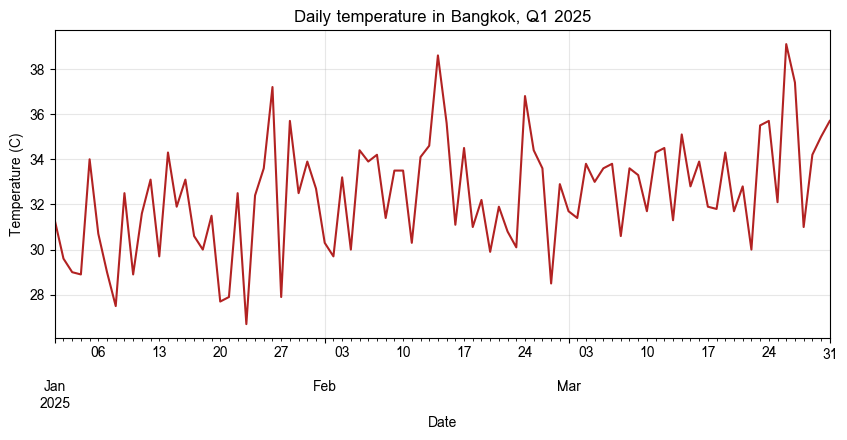

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

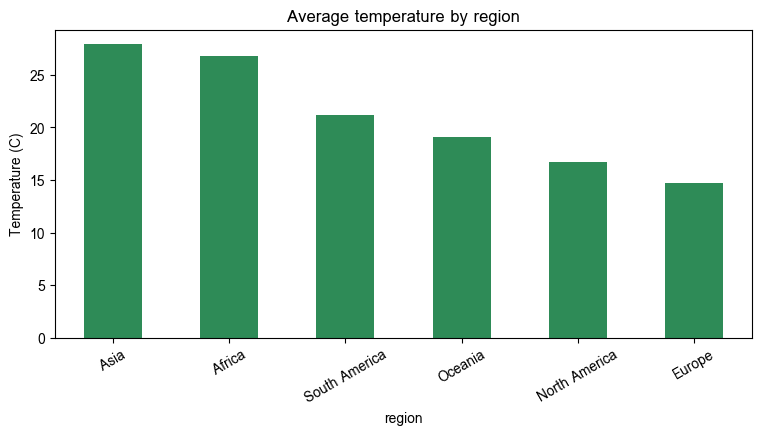

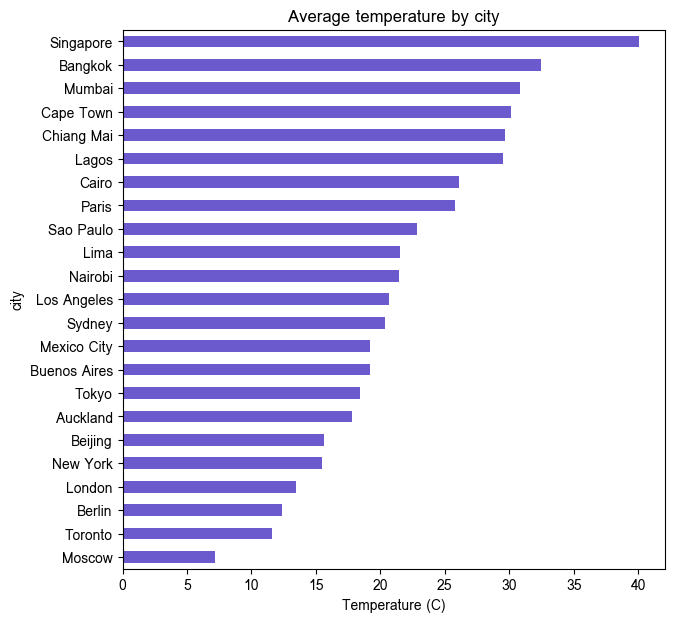

In [98]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

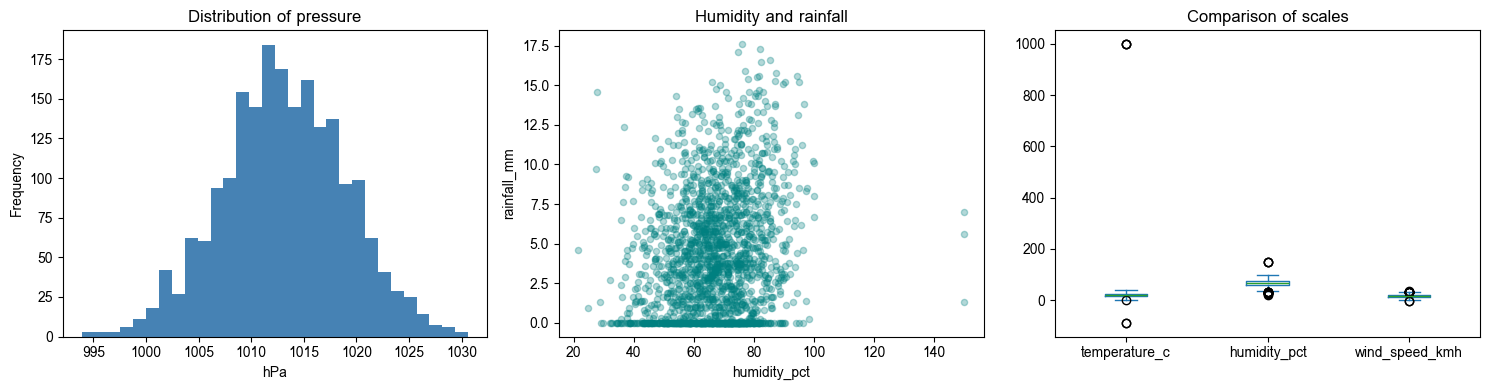

In [99]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

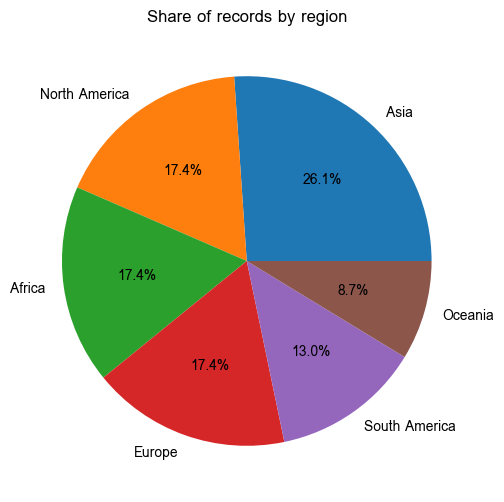

In [100]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

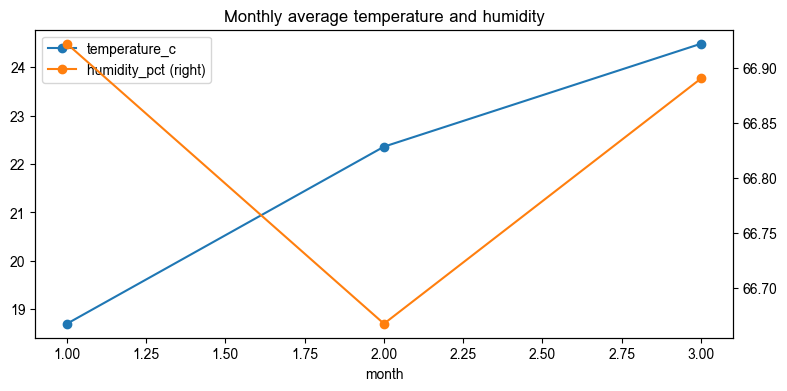

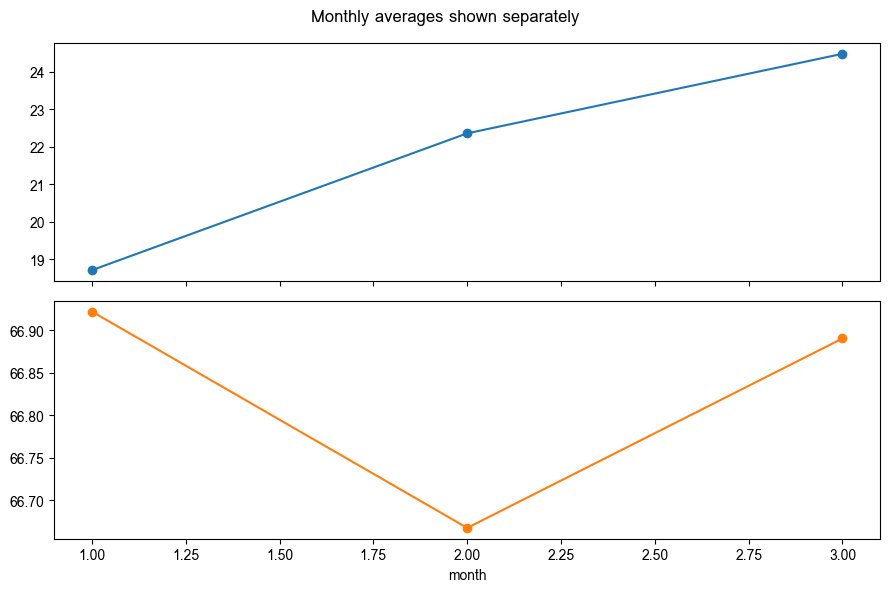

In [101]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

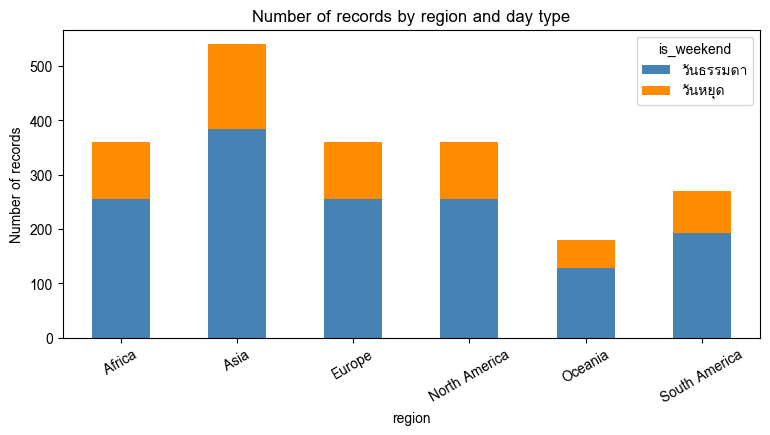

In [102]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

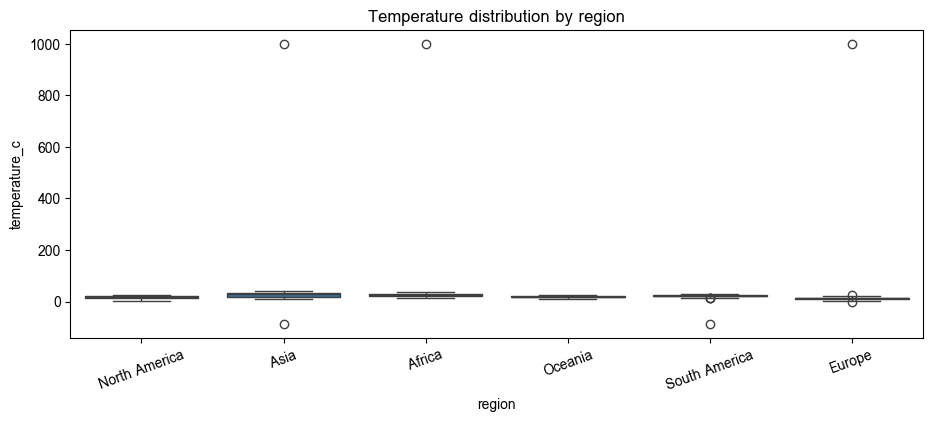

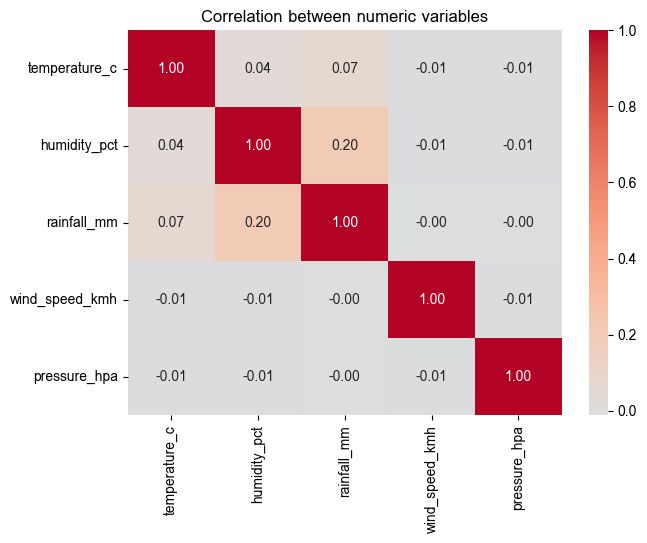

In [103]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

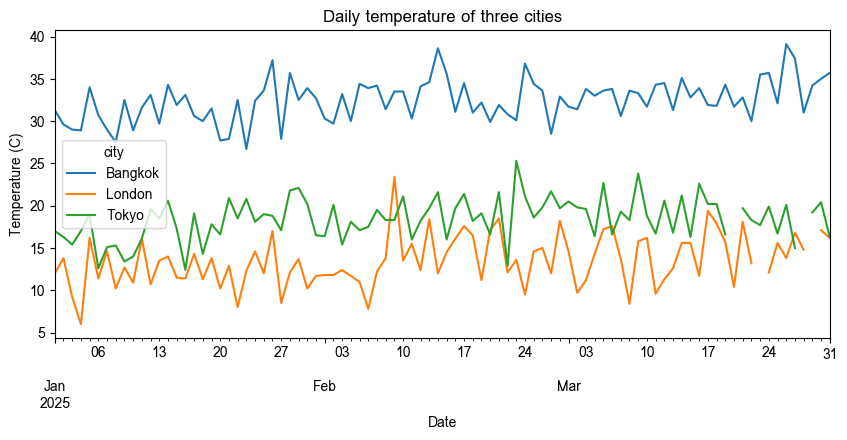

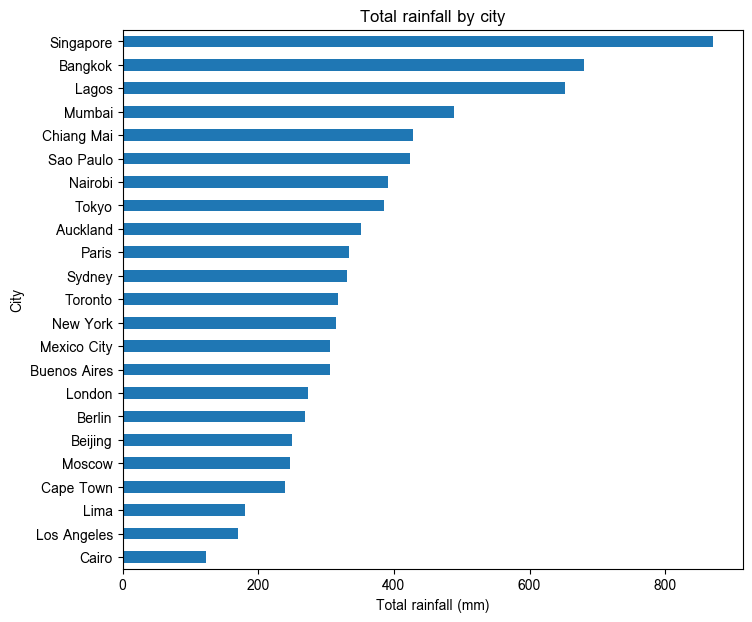

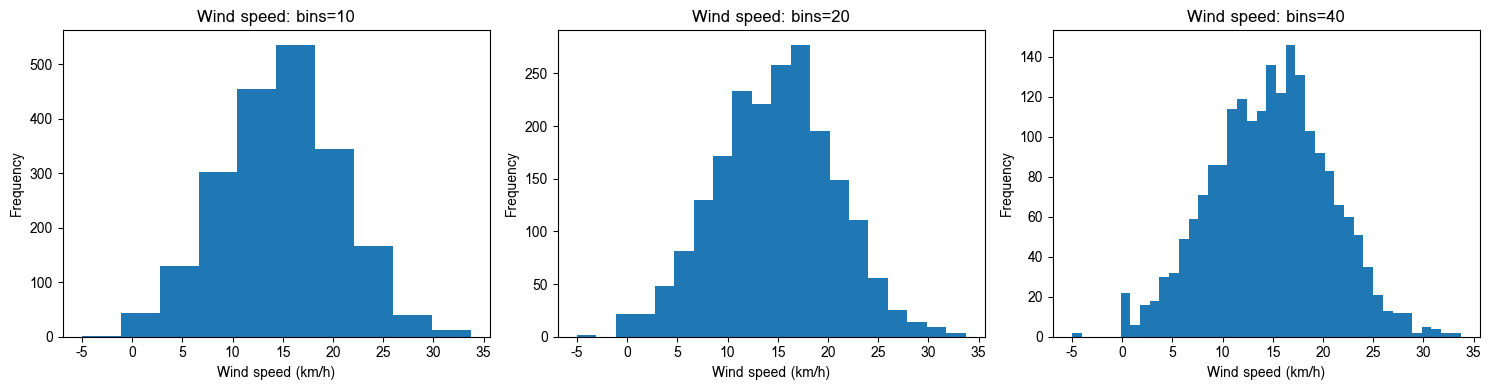

อธิบาย bins: bins น้อยทำให้กราฟเรียบและเห็นภาพรวมแต่ซ่อนรายละเอียด; bins มากแสดงรายละเอียดมากขึ้นแต่กราฟอาจดูผันผวน/เป็น noise จึงควรเลือกให้เหมาะกับจำนวนข้อมูลและรูปแบบการกระจาย


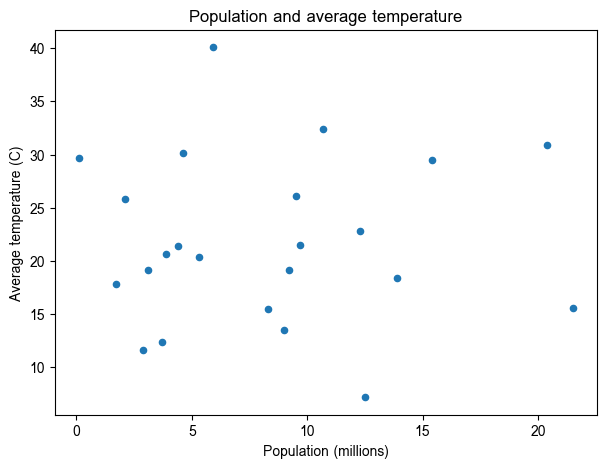

In [104]:
# คำตอบข้อ 17.1
plot_df = df.merge(city_info[[c for c in ["city", "population_millions"] if c in city_info.columns]], on="city", how="left")
three_cities = [c for c in ["Bangkok", "Tokyo", "London"] if c in df["city"].unique()][:3]
line_data = (df[df["city"].isin(three_cities)]
             .pivot_table(index="date", columns="city", values="temperature_c", aggfunc="mean"))
ax=line_data.plot(figsize=(10,4), title="Daily temperature of three cities")
ax.set_xlabel("Date"); ax.set_ylabel("Temperature (C)"); plt.show()

rain_city=df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=True)
ax=rain_city.plot(kind="barh", figsize=(8,7), title="Total rainfall by city")
ax.set_xlabel("Total rainfall (mm)"); ax.set_ylabel("City"); plt.show()

fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,b in zip(axes,[10,20,40]):
    df["wind_speed_kmh"].plot(kind="hist",bins=b,ax=ax)
    ax.set_title(f"Wind speed: bins={b}"); ax.set_xlabel("Wind speed (km/h)")
plt.tight_layout(); plt.show()
print("อธิบาย bins: bins น้อยทำให้กราฟเรียบและเห็นภาพรวมแต่ซ่อนรายละเอียด; bins มากแสดงรายละเอียดมากขึ้นแต่กราฟอาจดูผันผวน/เป็น noise จึงควรเลือกให้เหมาะกับจำนวนข้อมูลและรูปแบบการกระจาย")

city_scatter=(plot_df.groupby("city").agg(population_millions=("population_millions","first"),avg_temp=("temperature_c","mean")).dropna())
ax=city_scatter.plot(kind="scatter",x="population_millions",y="avg_temp",figsize=(7,5),title="Population and average temperature")
ax.set_xlabel("Population (millions)"); ax.set_ylabel("Average temperature (C)"); plt.show()


### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

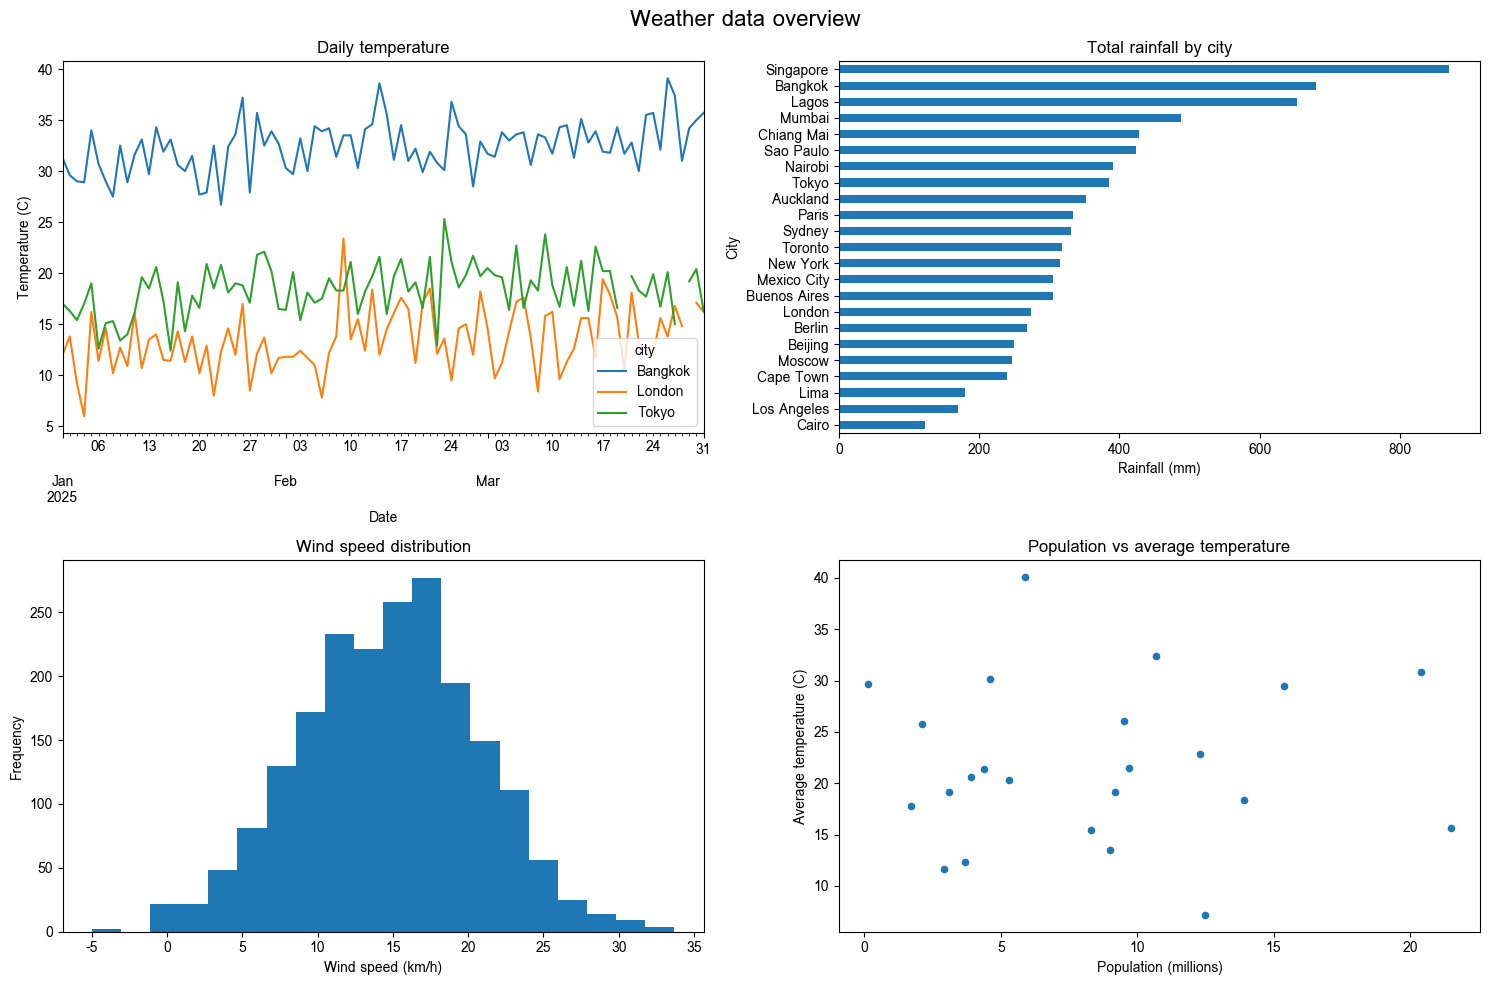

In [105]:
# คำตอบข้อ 17.2
plot_df = df.merge(city_info[[c for c in ["city", "population_millions"] if c in city_info.columns]], on="city", how="left")
three_cities=[c for c in ["Bangkok","Tokyo","London"] if c in df["city"].unique()][:3]
line_data=df[df["city"].isin(three_cities)].pivot_table(index="date",columns="city",values="temperature_c",aggfunc="mean")
rain_city=df.groupby("city")["rainfall_mm"].sum().sort_values()
city_scatter=plot_df.groupby("city").agg(population_millions=("population_millions","first"),avg_temp=("temperature_c","mean")).dropna()
fig,axes=plt.subplots(2,2,figsize=(15,10))
line_data.plot(ax=axes[0,0]); axes[0,0].set_title("Daily temperature"); axes[0,0].set_xlabel("Date"); axes[0,0].set_ylabel("Temperature (C)")
rain_city.plot(kind="barh",ax=axes[0,1]); axes[0,1].set_title("Total rainfall by city"); axes[0,1].set_xlabel("Rainfall (mm)"); axes[0,1].set_ylabel("City")
df["wind_speed_kmh"].plot(kind="hist",bins=20,ax=axes[1,0]); axes[1,0].set_title("Wind speed distribution"); axes[1,0].set_xlabel("Wind speed (km/h)"); axes[1,0].set_ylabel("Frequency")
city_scatter.plot(kind="scatter",x="population_millions",y="avg_temp",ax=axes[1,1]); axes[1,1].set_title("Population vs average temperature"); axes[1,1].set_xlabel("Population (millions)"); axes[1,1].set_ylabel("Average temperature (C)")
plt.suptitle("Weather data overview",fontsize=16); plt.tight_layout(); plt.show()


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

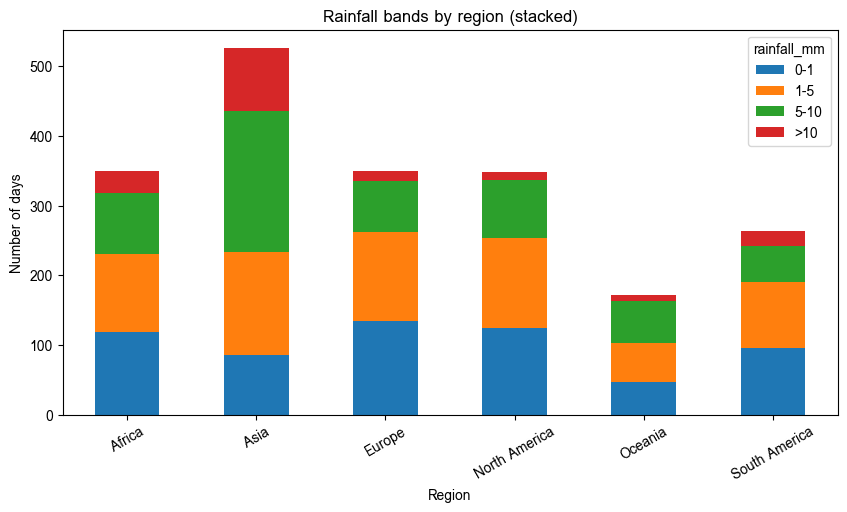

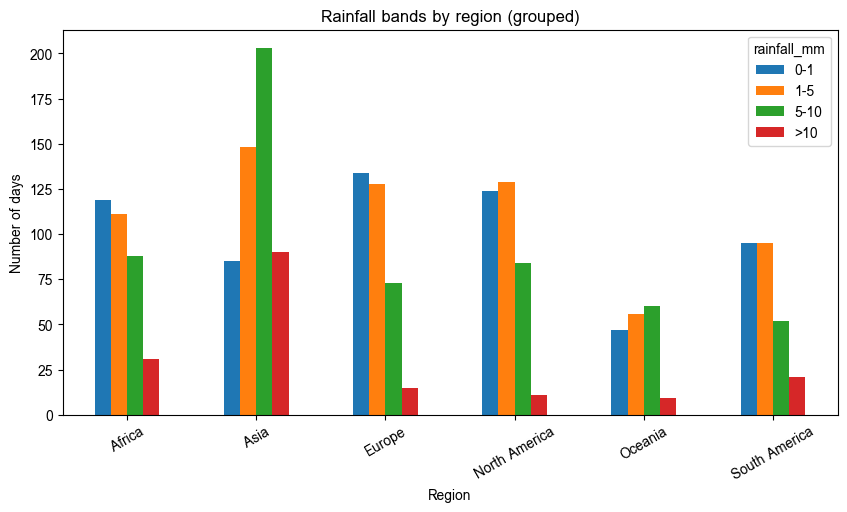

อธิบาย: stacked เหมาะเมื่อสนใจทั้งยอดรวมของแต่ละภูมิภาคและองค์ประกอบของช่วงฝนในแท่งเดียว ส่วน grouped/stacked=False เหมาะเมื่อเป้าหมายหลักคือเปรียบเทียบช่วงฝนเดียวกันข้ามภูมิภาค เพราะทุกแท่งเริ่มจากฐานเดียวกันและอ่านความสูงได้ง่ายกว่า


In [106]:
# คำตอบข้อ 17.3
rain_band=pd.cut(df["rainfall_mm"],bins=[-0.001,1,5,10,np.inf],labels=["0-1","1-5","5-10",">10"])
rain_ct=pd.crosstab(df["region"],rain_band)
ax=rain_ct.plot(kind="bar",stacked=True,figsize=(10,5),title="Rainfall bands by region (stacked)"); ax.set_xlabel("Region"); ax.set_ylabel("Number of days"); plt.xticks(rotation=30); plt.show()
ax=rain_ct.plot(kind="bar",stacked=False,figsize=(10,5),title="Rainfall bands by region (grouped)"); ax.set_xlabel("Region"); ax.set_ylabel("Number of days"); plt.xticks(rotation=30); plt.show()
print("อธิบาย: stacked เหมาะเมื่อสนใจทั้งยอดรวมของแต่ละภูมิภาคและองค์ประกอบของช่วงฝนในแท่งเดียว ส่วน grouped/stacked=False เหมาะเมื่อเป้าหมายหลักคือเปรียบเทียบช่วงฝนเดียวกันข้ามภูมิภาค เพราะทุกแท่งเริ่มจากฐานเดียวกันและอ่านความสูงได้ง่ายกว่า")


### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

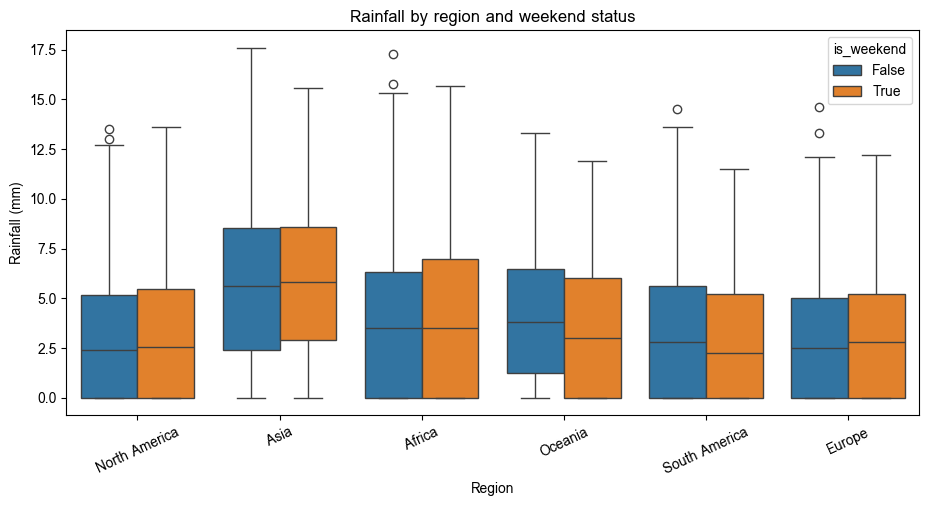

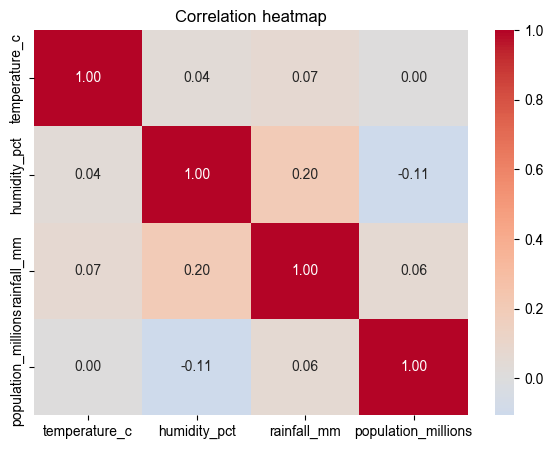

ตีความ: boxplot ใช้เปรียบเทียบค่ากลาง การกระจาย และ outlier ของฝนระหว่างภูมิภาค/วันหยุด ส่วน heatmap แสดงทิศทางและความแรงของความสัมพันธ์เชิงเส้น ค่าที่ใกล้ 1 หรือ -1 สัมพันธ์มากและใกล้ 0 สัมพันธ์เชิงเส้นน้อย
ค่าสหสัมพันธ์ที่ได้จริง:
                     temperature_c  humidity_pct  rainfall_mm  \
temperature_c                1.000         0.038        0.068   
humidity_pct                 0.038         1.000        0.199   
rainfall_mm                  0.068         0.199        1.000   
population_millions          0.003        -0.106        0.061   

                     population_millions  
temperature_c                      0.003  
humidity_pct                      -0.106  
rainfall_mm                        0.061  
population_millions                1.000  


In [107]:
# คำตอบข้อ 17.4
plot_df=df.merge(city_info[[c for c in ["city","population_millions"] if c in city_info.columns]],on="city",how="left")
fig,ax=plt.subplots(figsize=(11,5)); sns.boxplot(data=plot_df,x="region",y="rainfall_mm",hue="is_weekend",ax=ax); ax.set_title("Rainfall by region and weekend status"); ax.set_xlabel("Region"); ax.set_ylabel("Rainfall (mm)"); plt.xticks(rotation=25); plt.show()
cols=["temperature_c","humidity_pct","rainfall_mm","population_millions"]
corr=plot_df[cols].corr()
fig,ax=plt.subplots(figsize=(7,5)); sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,ax=ax); ax.set_title("Correlation heatmap"); plt.show()
print("ตีความ: boxplot ใช้เปรียบเทียบค่ากลาง การกระจาย และ outlier ของฝนระหว่างภูมิภาค/วันหยุด ส่วน heatmap แสดงทิศทางและความแรงของความสัมพันธ์เชิงเส้น ค่าที่ใกล้ 1 หรือ -1 สัมพันธ์มากและใกล้ 0 สัมพันธ์เชิงเส้นน้อย")
print("ค่าสหสัมพันธ์ที่ได้จริง:")
print(corr.round(3))


---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

SD อุณหภูมิรายภูมิภาค
region
Asia             7.16
Africa           4.88
North America    4.52
Europe           4.07
Oceania          3.08
South America    3.06
Name: temperature_c, dtype: float64

ภูมิภาคที่แปรปรวนที่สุด = Asia
SD รายเมืองในภูมิภาคนั้น
city
Beijing       2.87
Chiang Mai    2.86
Singapore     2.71
Mumbai        2.54
Tokyo         2.52
Bangkok       2.49
Name: temperature_c, dtype: float64


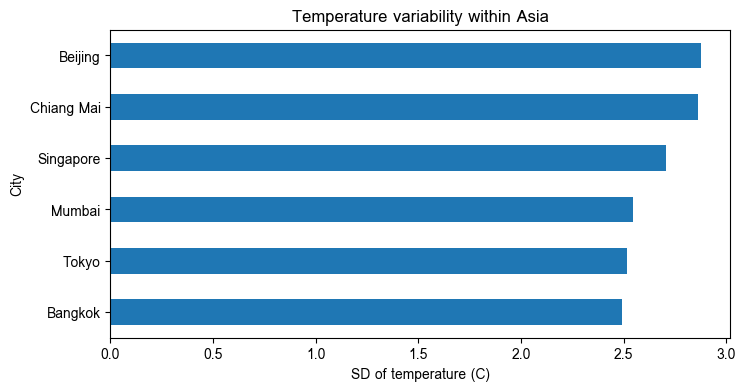

สรุป: เปรียบเทียบ SD รายเมืองกับ SD ของภูมิภาคด้านบน หากเมืองอันดับแรกสูงกว่าที่เหลือชัดเจน แสดงว่าความแปรปรวนถูกขับโดยเมืองนั้นเป็นหลัก; หากค่าใกล้กัน แสดงว่าเป็นลักษณะร่วมของหลายเมืองในภูมิภาค


In [108]:
# คำตอบข้อ 18.1
clean18 = df.assign(temperature_c=df["temperature_c"].where(df["temperature_c"].between(-60,60)))
region_var = clean18.groupby("region")["temperature_c"].std().sort_values(ascending=False)
worst_region = region_var.index[0]
city_var = (clean18[clean18["region"].eq(worst_region)].groupby("city")["temperature_c"].std().sort_values(ascending=False))
print("SD อุณหภูมิรายภูมิภาค")
print(region_var.round(2))
print("\nภูมิภาคที่แปรปรวนที่สุด =",worst_region)
print("SD รายเมืองในภูมิภาคนั้น")
print(city_var.round(2))
ax=city_var.sort_values().plot(kind="barh",figsize=(8,4),title=f"Temperature variability within {worst_region}"); ax.set_xlabel("SD of temperature (C)"); ax.set_ylabel("City"); plt.show()
print("สรุป: เปรียบเทียบ SD รายเมืองกับ SD ของภูมิภาคด้านบน หากเมืองอันดับแรกสูงกว่าที่เหลือชัดเจน แสดงว่าความแปรปรวนถูกขับโดยเมืองนั้นเป็นหลัก; หากค่าใกล้กัน แสดงว่าเป็นลักษณะร่วมของหลายเมืองในภูมิภาค")


2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

Top 5 ตามสัดส่วน
            heavy_days  observed_days  heavy_share
city                                              
Singapore           44             90     0.488889
Bangkok             23             87     0.264368
Lagos               22             88     0.250000
Sao Paulo           11             88     0.125000
Chiang Mai           9             85     0.105882

Top 5 ตามจำนวนวัน
              heavy_days  observed_days  heavy_share
city                                                
Singapore             44             90     0.488889
Bangkok               23             87     0.264368
Lagos                 22             88     0.250000
Sao Paulo             11             88     0.125000
Buenos Aires           9             88     0.102273


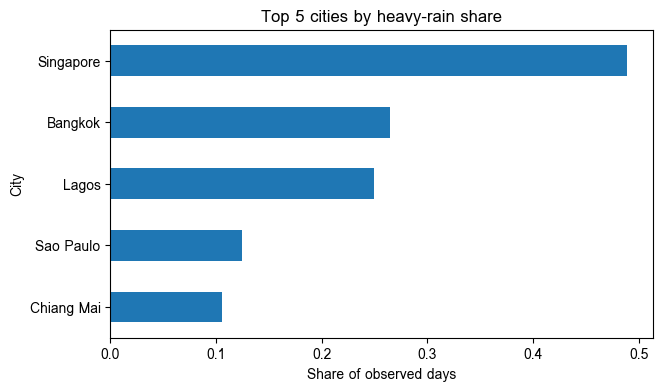

สรุป: สองอันดับอาจต่างกันเพราะจำนวนวันที่ rainfall_mm มีข้อมูลของแต่ละเมืองอาจไม่เท่ากัน จำนวนวันดิบสะท้อนจำนวนเหตุการณ์ แต่สัดส่วนปรับด้วยจำนวนวันที่สังเกตได้จึงเปรียบเทียบความถี่ระหว่างเมืองได้ยุติธรรมกว่า


In [109]:
# คำตอบข้อ 18.2
heavy18=(df.groupby("city").agg(heavy_days=("rainfall_mm",lambda s:(s>10).sum()),observed_days=("rainfall_mm","count")))
heavy18["heavy_share"]=heavy18["heavy_days"]/heavy18["observed_days"]
by_share=heavy18.nlargest(5,"heavy_share")
by_count=heavy18.nlargest(5,"heavy_days")
comparison=by_share.join(by_count[["heavy_days"]],rsuffix="_rank_by_count",how="outer")
print("Top 5 ตามสัดส่วน")
print(by_share)
print("\nTop 5 ตามจำนวนวัน")
print(by_count)
ax=by_share["heavy_share"].sort_values().plot(kind="barh",figsize=(7,4),title="Top 5 cities by heavy-rain share"); ax.set_xlabel("Share of observed days"); ax.set_ylabel("City"); plt.show()
print("สรุป: สองอันดับอาจต่างกันเพราะจำนวนวันที่ rainfall_mm มีข้อมูลของแต่ละเมืองอาจไม่เท่ากัน จำนวนวันดิบสะท้อนจำนวนเหตุการณ์ แต่สัดส่วนปรับด้วยจำนวนวันที่สังเกตได้จึงเปรียบเทียบความถี่ระหว่างเมืองได้ยุติธรรมกว่า")


3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

                     population_millions  avg_temp  total_rain
population_millions                1.000     0.014       0.128
avg_temp                           0.014     1.000       0.658
total_rain                         0.128     0.658       1.000


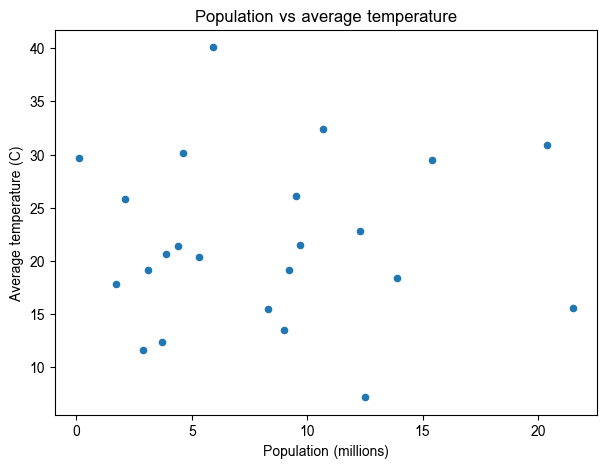

สรุป: ให้พิจารณาค่า correlation ของ population_millions กับ avg_temp และ total_rain ด้านบน โดยเครื่องหมายบอกทิศทางและค่าสัมบูรณ์บอกความแรงของความสัมพันธ์เชิงเส้น
ข้อควรระวัง: correlation ไม่ได้พิสูจน์เหตุและผล และมีเพียง 23 เมือง ปัจจัยแฝง เช่น ละติจูด ภูมิอากาศ ภูมิประเทศ และฤดูกาล อาจเป็นสาเหตุของความสัมพันธ์ที่เห็น นอกจากนี้ total_rain อาจได้รับผลจากจำนวนวันที่มีข้อมูล


In [110]:
# คำตอบข้อ 18.3
city18=(df.groupby("city").agg(avg_temp=("temperature_c","mean"),total_rain=("rainfall_mm","sum")).reset_index()
        .merge(city_info[["city","population_millions"]],on="city",how="left"))
corr18=city18[["population_millions","avg_temp","total_rain"]].corr()
print(corr18.round(3))
fig,ax=plt.subplots(figsize=(7,5)); city18.plot(kind="scatter",x="population_millions",y="avg_temp",ax=ax,title="Population vs average temperature"); ax.set_xlabel("Population (millions)"); ax.set_ylabel("Average temperature (C)"); plt.show()
print("สรุป: ให้พิจารณาค่า correlation ของ population_millions กับ avg_temp และ total_rain ด้านบน โดยเครื่องหมายบอกทิศทางและค่าสัมบูรณ์บอกความแรงของความสัมพันธ์เชิงเส้น")
print("ข้อควรระวัง: correlation ไม่ได้พิสูจน์เหตุและผล และมีเพียง 23 เมือง ปัจจัยแฝง เช่น ละติจูด ภูมิอากาศ ภูมิประเทศ และฤดูกาล อาจเป็นสาเหตุของความสัมพันธ์ที่เห็น นอกจากนี้ total_rain อาจได้รับผลจากจำนวนวันที่มีข้อมูล")


4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

           region  month  total_rain  heavy_days  avoid_score
0          Africa      1       506.8          12         0.38
4            Asia      2      1043.2          38         4.92
8          Europe      3       372.5           7        -0.61
9   North America      1       422.2           4        -0.73
14        Oceania      3       240.7           6        -1.19
15  South America      1       303.5           8        -0.76


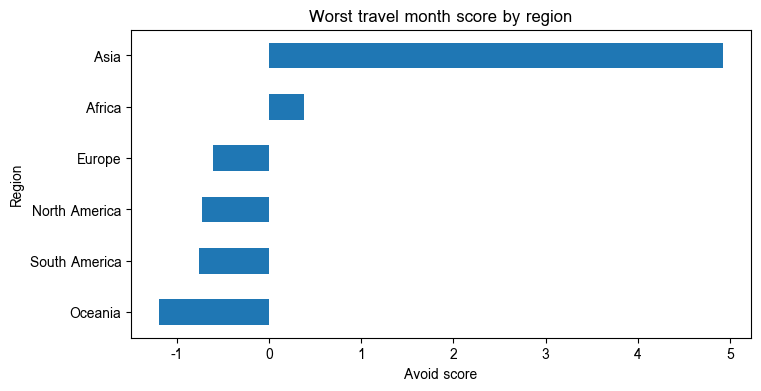

สรุป: เดือนที่แสดงในตารางคือเดือนที่ควรหลีกเลี่ยงที่สุดของแต่ละภูมิภาคตามเกณฑ์นี้ เลือกฝนรวมเพื่อสะท้อนปริมาณฝนโดยรวม และจำนวนวันฝนหนักเพื่อสะท้อนความถี่ของวันที่อาจรบกวนการเดินทาง การทำ z-score ช่วยให้สองตัวชี้วัดที่มีหน่วยต่างกันนำมารวมคะแนนได้


In [111]:
# คำตอบข้อ 18.4
# เกณฑ์: สร้างคะแนนจาก 2 ปัจจัยที่ทำให้เดินทางไม่สะดวก คือฝนรวมและจำนวนวันฝนหนัก (>10 mm)
# normalize ภายในทั้งตาราง region-month ด้วย z-score แล้วรวมคะแนนเท่ากัน
travel=(df.groupby(["region","month"]).agg(total_rain=("rainfall_mm","sum"),heavy_days=("rainfall_mm",lambda s:(s>10).sum()),avg_temp=("temperature_c","mean")).reset_index())
for c in ["total_rain","heavy_days"]:
    sd=travel[c].std()
    travel[c+"_z"]=(travel[c]-travel[c].mean())/sd if sd else 0
travel["avoid_score"]=travel["total_rain_z"]+travel["heavy_days_z"]
worst=(travel.loc[travel.groupby("region")["avoid_score"].idxmax(),["region","month","total_rain","heavy_days","avoid_score"]].sort_values("region"))
print(worst.round(2))
plot=worst.set_index("region")["avoid_score"].sort_values(); ax=plot.plot(kind="barh",figsize=(8,4),title="Worst travel month score by region"); ax.set_xlabel("Avoid score"); ax.set_ylabel("Region"); plt.show()
print("สรุป: เดือนที่แสดงในตารางคือเดือนที่ควรหลีกเลี่ยงที่สุดของแต่ละภูมิภาคตามเกณฑ์นี้ เลือกฝนรวมเพื่อสะท้อนปริมาณฝนโดยรวม และจำนวนวันฝนหนักเพื่อสะท้อนความถี่ของวันที่อาจรบกวนการเดินทาง การทำ z-score ช่วยให้สองตัวชี้วัดที่มีหน่วยต่างกันนำมารวมคะแนนได้")


---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️